[<img src="images/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/si-md2/blob/main/si-md2/notebooks_alunos/cap03/cap03_aluno.ipynb)
[<img src="images/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/si-md2)

# Classificação e Árvores de Decisão

## Introdução

É de grande interesse, em muitas situações, conseguir classificar antecipadamente o tipo de problema apresentado por um paciente com base nos sintomas relatados e tomar medidas para combater determinada doença em seu estágio inicial. Em muitos casos reais isso tem sido possível graças à análise minuciosa de Bases de Dados contendo anotações médicas de outros pacientes com soluções bem sucedidas previamente documentadas.

Em instituições financeiras, para um gerente de banco nem sempre é algo simples fazer uma avaliação de risco sobre a concessão de empréstimos de alto valor. Com base em dados de transações anteriores e nas características específicas de cada cliente, quase sempre é possível extrair automaticamente informações não óbvias que ajudam a classificar um correntista como bom ou mau pagador.

Estes são apenas alguns casos em que se verifica que há sempre informações úteis e não evidentes em grandes Bases de Dados. Estas informações podem ser automaticamente extraídas com Mineração de Dados e interpretadas de modo a constituir conhecimento especializado e útil para a tomada de decisão. A representação do conhecimento através de Árvores de Decisão vai ser o tema deste capítulo.

## Classificação

Classificação é uma forma de **modelagem preditiva**, isto é, com base nos **atributos de entrada** de um objeto é possível predizer o **atributo de saída** desse objeto. Na prática, os Exemplos de uma Base de Dados estão previamente rotulados em duas ou mais classes para serem utilizados num processo de treinamento, cujo fim é criar uma estrutura de representação do conhecimento contido nessa Base de Dados.

Quando se fala em Exemplos previamente rotulados geralmente se subentende que eles serão usados em Aprendizado Supervisionado de Máquina. Os rótulos ou classes dos Exemplos orientam o processo de treinamento, ao final do qual se obtém um Modelo que sintetiza todo o conhecimento contido nas variáveis ou nos atributos. Este Modelo pode então ser usado para prever o valor da variável alvo ou do atributo de saída de novos Exemplos desconhecidos.

O objetivo então da Classificação é predizer em que classe um novo Exemplo, não pertencente ao Conjunto de Treinamento, deve ser colocado. Para que esta tarefa possa ser adequadamente desempenhada é necessário extrair da Base de Dados uma estrutura de conhecimento, tal como Árvores de Decisão ou Regras de Classificação.

Em outras palavras, o Modelo induzido por inferência é equivalente a uma função que mapeia valores de entrada, geralmente denominados variáveis independentes ou explicativas, a um único valor de saída, geralmente denominado variável dependente ou alvo. Na **Classificação**, a variável de saída, via de regra, é discreta (ou categórica), enquanto que na **Regressão** a variável de saída é contínua.

A [Figura 3.1](#fig-3-1) ilustra simplificadamente um estudo clássico introduzido por (Fisher (1936)), cujo artigo original apresenta três conjuntos com 50 amostras (ou Exemplos), totalizando 150 medidas do comprimento e da largura de uma pequena flor conhecida como Flor de Lis ou Íris. De acordo com os atributos de entrada "Comprimento" e "Largura" da pétala, cada Exemplo dessa flor pode ser classificado em uma das três classes: Setosa, Versicolor ou Virgínica.

As linhas tracejadas no gráfico ajudam a entender por que a classificação da Íris do tipo Setosa pode ser mais simples que a dos tipos Versicolor e Virgínica. Como a Íris do tipo Setosa apresenta largura e comprimento da pétala bem menor que as outras duas, basta considerar apenas um dos atributos, digamos Comprimento $< 2,5$ cm, para poder classificá-la corretamente. No caso dos tipos Versicolor e Virgínica, tanto o atributo Comprimento quanto Largura se sobrepõem em algumas regiões do gráfico e, portanto, poderá haver erro associado à classificação destes tipos de Íris.

<figure id="fig-3-1" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-1.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.1:</strong> Representação do Estudo da Flor Íris com Dois Atributos <sup title="1">[1]</sup> <sup title="2">[2]</sup> <sup title="3">[3]</sup>.</figcaption>
</figure>








<hr><div style="font-size: 0.85em; color: #555;"><strong>Notas:</strong><br>
[1] Fonte: <a href="http://en.wikipedia.org/wiki/File:Iris_virginica.jpg">Wikimedia Commons - Iris virginica</a>     (Acessado em 03.03.26).<br>
[2] Fonte: <a href="http://en.wikipedia.org/wiki/File:Iris_versicolor_3.jpg">Wikimedia Commons - Iris versicolor</a>     (Acessado em 03.03.26).<br>
[3] Fonte: <a href="http://en.wikipedia.org/wiki/File:Kosaciec_szczecinkowaty_Iris_setosa.jpg">Wikimedia Commons - Iris setosa</a>     (Acessado em 03.03.26).<br>
</div>

Em muitas aplicações práticas é perfeitamente aceitável a utilização de
algoritmos relativamente simples que produzam um modelo claro de
representação do conhecimento, mesmo que isso implique uma certa taxa de
erro na classificação. Modelos facilmente compreensíveis de
representação de conhecimento, como Árvores de Decisão e Regras de
Classificação, permitem que um especialista avalie o modelo e detecte
problemas em sua estrutura. Tanto para o médico quanto para o gerente de
banco que se utilizam de um modelo de classificação para auxiliar em sua
decisão, é importante que eles consigam interpretar todos os passos
lógicos utilizados pelo sistema para chegar àquela classificação e
avaliá-los à luz da respectiva experiência profissional.

Por outro lado, em muitas aplicações o mais importante é otimizar a taxa
de acerto ou a precisão do modelo, mesmo que isso implique certa perda
de clareza, de simplicidade ou de desempenho do modelo. Redes Neurais e
Máquinas de Vetor de Suporte são duas ilustrações de técnicas que podem
oferecer alta precisão, mas que utilizam modelos de classificação
difíceis de entender. É comum o uso dessas duas técnicas na área de
aplicações financeiras, porque investidores geralmente estão mais
interessados no ganho obtido diariamente na aplicação mais bem
classificada do que no modelo matemático explicativo. Por esta razão, a
decisão de usar um **modelo orientado ao conhecimento** ou um **modelo
tipo caixa-preta** deve ser feita caso a caso.

Para a tarefa de Classificação, os dois modelos orientados ao
conhecimento mais comuns de representação são Árvores de Decisão e
Regras de Classificação. Ambos são logicamente equivalentes e permitem
que a partir de uma Árvore de Decisão seja possível obter as
correspondentes Regras de Classificação, e vice-versa, embora a obtenção
de Árvores a partir de Regras seja um processo mais complexo. Há, porém,
vantagens e desvantagens observadas durante a geração desses modelos,
que serão discutidas mais a frente.

A [Figura 3.2](#fig-3-2) apresenta modelos simplificados de uma **Árvore de
Decisão** e das correspondentes **Regras de Classificação** para o caso
da flor Íris. Com estes modelos simplificados, os erros de classificação
ilustrados na [Figura 3.1](#fig-3-1) novamente se repetiriam aqui. Para reduzir a
taxa de erros, veremos que será necessário usar métodos de aprendizado
mais refinados ou complexos.



<figure id="fig-3-2" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-2.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.2:</strong> Modelos Equivalentes: (a) Árvore de Decisão e (b) Regras de Classificação.</figcaption>
</figure>

Dependendo da representação desejada, diferentes métodos de inferência
serão usados sobre os dados. Mesmo que um modelo faça classificação com
erros, é importante observar que cada Exemplo sempre pertencerá a uma
única classe.

## Árvores de Decisão

Numa Árvore de Decisão cada **atributo** é representado por um **nó de decisão**, cuja função é testar o valor desse atributo. Uma **classe** é representada por um **nó folha**, que reúne todos os Exemplos que chegarem a ele depois de satisfazerem os testes dos nós de decisão intermediários. Portanto, numa Árvore de Decisão, a classificação de um Exemplo desconhecido implica percorrer toda a árvore a partir de um **nó raiz**, testando atributos em sucessivos **nós internos** até chegar a um **nó folha**, que lhe atribuirá uma **classe**. O objetivo de uma Árvore de Decisão é retornar uma classe para um Exemplo desconhecido.



## Indução de Árvores de Decisão

Uma Árvore de Decisão pode ser construída de forma recursiva, dividindo sucessivamente o conjunto de atributos em subconjuntos. Primeiramente escolhemos um elemento do conjunto de atributos para ser o nó raiz e adicionamos uma aresta para cada um dos possíveis valores que este atributo pode assumir. A seguir, repetimos o processo em cada uma das arestas com os atributos restantes até que todos os Exemplos considerados pertençam à mesma classe.

Gerar uma Árvore de Decisão com escolha aleatória dos atributos não é difícil, porém dependendo da ordem dos atributos, diferentes árvores serão geradas. Isso significa que uma mesma Base de Dados pode produzir muitas Árvores de Decisão funcionalmente equivalentes, mas com tamanhos distintos. Como estamos interessados nos modelos mais compactos, é interessante encontrar critérios que ajudem a decidir sobre a ordem em que os atributos devem aparecer na Árvore de Decisão.

Para ilustrar esta questão, vamos utilizar como caso de estudo novamente a clássica Tabela do Tempo ([Tabela 3.1](#tbl-3-1)), introduzida por Quinlan (1986), tendo como atributos de entrada "Dia", "Temperatura", "Umidade" e \"Vento", e como atributo de saída (ou classe) "Partida". Para ser mais preciso, na realidade temos duas classes "Sim" e "Não", e queremos construir uma Árvore de Decisão que represente de forma compacta os Exemplos contidos nessa tabela. A seguir, com a Árvore de Decisão obtida, dado um novo Exemplo, vamos tentar predizer se vai ou não haver "Partida" num determinado dia, sendo a resposta a combinação linear dos atributos de entrada.


<a id="tbl-3-1"></a>

**Tabela 3.1:** Tabela do Tempo.

| Dia | Temperatura | Umidade | Vento | Partida |
| --- | --- | --- | --- | --- |
| Ensolarado | Elevada | Alta | Falso | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Elevada | Alta | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |
| Nublado | Elevada | Alta | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | Alta | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Baixa | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Baixa | Normal | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |
| Nublado | Baixa | Normal | Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | Amena | Alta | Falso | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Baixa | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | Amena | Normal | Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Nublado | Amena | Alta | Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Nublado | Elevada | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | Alta | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |


Inicialmente vamos considerar separadamente para o nó raiz cada um dos quatro atributos possíveis e ver como o atributo de saída "Partida" se divide em "Sim" e "Não". Na [Tabela 3.2](#tbl-3-2) é ressaltado o atributo "Dia", na [Tabela 3.3](#tbl-3-3), "Temperatura", na [Tabela 3.4](#tbl-3-4), "Umidade", e na [Tabela 3.5](#tbl-3-5), "Vento".

Como estamos interessados em construir uma árvore compacta, dentre os quatro atributos candidatos para nó raiz, o atributo "Dia" parece o mais promissor porque dentre as três arestas que teremos de colocar neste nó ("Ensolarado", "Nublado" e "Chuvoso"), a aresta para "Nublado" tem **todos** seus elementos pertencentes à mesma classe "Sim" e, portanto, esta aresta da Árvore de Decisão termina aqui com um nó folha "Sim".

<table style="width:100%; border:none; border-collapse:collapse;"><tr style="border:none;">
<td style="vertical-align:top; padding:4px; width:25%; border:none;"><a id="tbl-3-2"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.2:</strong> Dia</div>

| Dia | Partida |
| --- | --- |
| Ensolarado | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | ${\color{blue}{\textbf{Não}}}$ |
| ${\color{green}{\textbf{Nublado}}}$ | ${\color{green}{\textbf{Sim}}}$ |
| ${\color{green}{\textbf{Nublado}}}$ | ${\color{green}{\textbf{Sim}}}$ |
| ${\color{green}{\textbf{Nublado}}}$ | ${\color{green}{\textbf{Sim}}}$ |
| ${\color{green}{\textbf{Nublado}}}$ | ${\color{green}{\textbf{Sim}}}$ |
| Chuvoso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | ${\color{blue}{\textbf{Não}}}$ |
| Chuvoso | ${\color{blue}{\textbf{Não}}}$ |

</td>
<td style="vertical-align:top; padding:4px; width:25%; border:none;"><a id="tbl-3-3"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.3:</strong> Temperatura</div>

| Temperatura | Partida |
| --- | --- |
| Elevada | ${\color{red}{\textbf{Sim}}}$ |
| Elevada | ${\color{red}{\textbf{Sim}}}$ |
| Elevada | ${\color{blue}{\textbf{Não}}}$ |
| Elevada | ${\color{blue}{\textbf{Não}}}$ |
| Amena | ${\color{red}{\textbf{Sim}}}$ |
| Amena | ${\color{red}{\textbf{Sim}}}$ |
| Amena | ${\color{red}{\textbf{Sim}}}$ |
| Amena | ${\color{red}{\textbf{Sim}}}$ |
| Amena | ${\color{blue}{\textbf{Não}}}$ |
| Amena | ${\color{blue}{\textbf{Não}}}$ |
| Baixa | ${\color{red}{\textbf{Sim}}}$ |
| Baixa | ${\color{red}{\textbf{Sim}}}$ |
| Baixa | ${\color{red}{\textbf{Sim}}}$ |
| Baixa | ${\color{blue}{\textbf{Não}}}$ |

</td>
<td style="vertical-align:top; padding:4px; width:25%; border:none;"><a id="tbl-3-4"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.4:</strong> Umidade</div>

| Umidade | Partida |
| --- | --- |
| Alta | ${\color{red}{\textbf{Sim}}}$ |
| Alta | ${\color{red}{\textbf{Sim}}}$ |
| Alta | ${\color{red}{\textbf{Sim}}}$ |
| Alta | ${\color{blue}{\textbf{Não}}}$ |
| Alta | ${\color{blue}{\textbf{Não}}}$ |
| Alta | ${\color{blue}{\textbf{Não}}}$ |
| Alta | ${\color{blue}{\textbf{Não}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{blue}{\textbf{Não}}}$ |

</td>
<td style="vertical-align:top; padding:4px; width:25%; border:none;"><a id="tbl-3-5"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.5:</strong> Vento</div>

| Vento | Partida |
| --- | --- |
| Falso | ${\color{red}{\textbf{Sim}}}$ |
| Falso | ${\color{red}{\textbf{Sim}}}$ |
| Falso | ${\color{red}{\textbf{Sim}}}$ |
| Falso | ${\color{red}{\textbf{Sim}}}$ |
| Falso | ${\color{red}{\textbf{Sim}}}$ |
| Falso | ${\color{red}{\textbf{Sim}}}$ |
| Falso | ${\color{blue}{\textbf{Não}}}$ |
| Falso | ${\color{blue}{\textbf{Não}}}$ |
| Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |
| Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |
| Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |

</td>
</tr></table>


A [Figura 3.3](#fig-3-3) ilustra esta primeira iteração na construção de uma Árvore
de Decisão compacta.

<figure id="fig-3-3" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-3.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.3:</strong> Nó raiz para os dados do Tempo.</figcaption>
</figure>

Como nas arestas "Ensolarado" e "Chuvoso" há elementos tanto da classe "Sim" como da classe "Não" (veja [Tabela 3.2](#tbl-3-2)), outro atributo deve ser escolhido para cada aresta, e assim sucessivamente até que todos os elementos de um ramo pertençam a uma mesma classe. Como restam os atributos "Temperatura", "Umidade" e "Vento", analisando a [Tabela 3.1](#tbl-3-1), vamos testar cada um deles em combinação com a aresta "Ensolarado".

As Tabelas [3.6](#tbl-3-6), [3.7](#tbl-3-7) e [3.8](#tbl-3-8) mostram as combinações possíveis de "Dia=Ensolarado" com "Temperatura", "Umidade" e "Vento". Aqui também percebemos que "Umidade" parece ser a escolha mais promissora porque todos os elementos de "Umidade=Alta" correspondem à classe "Não" e todos os elementos com "Umidade=Normal" pertencem à classe "Sim". Portanto, temos mais dois nós folhas aqui, favorecendo a construção de uma árvore mais compacta.

<table style="width:100%; border:none; border-collapse:collapse;"><tr style="border:none;">
<td style="vertical-align:top; padding:4px; width:33%; border:none;"><a id="tbl-3-6"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.6:</strong> Temperatura</div>

| Dia | Temp. | Partida |
| --- | --- | --- |
| Ensolarado | Elevada | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Elevada | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Amena | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | Amena | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Baixa | ${\color{red}{\textbf{Sim}}}$ |

</td>
<td style="vertical-align:top; padding:4px; width:33%; border:none;"><a id="tbl-3-7"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.7:</strong> Umidade</div>

| Dia | Umidade | Partida |
| --- | --- | --- |
| ${\color{green}{\textbf{Ensolarado}}}$ | ${\color{green}{\textbf{Alta}}}$ | ${\color{green}{\textbf{Não}}}$ |
| ${\color{green}{\textbf{Ensolarado}}}$ | ${\color{green}{\textbf{Alta}}}$ | ${\color{green}{\textbf{Não}}}$ |
| ${\color{green}{\textbf{Ensolarado}}}$ | ${\color{green}{\textbf{Alta}}}$ | ${\color{green}{\textbf{Não}}}$ |
| ${\color{green}{\textbf{Ensolarado}}}$ | ${\color{green}{\textbf{Normal}}}$ | ${\color{green}{\textbf{Sim}}}$ |
| ${\color{green}{\textbf{Ensolarado}}}$ | ${\color{green}{\textbf{Normal}}}$ | ${\color{green}{\textbf{Sim}}}$ |

</td>
<td style="vertical-align:top; padding:4px; width:33%; border:none;"><a id="tbl-3-8"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.8:</strong> Vento</div>

| Dia | Vento | Partida |
| --- | --- | --- |
| Ensolarado | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | Falso | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Falso | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |

</td>
</tr></table>


A [Figura 3.4](#fig-3-4) ilustra a segunda iteração do algoritmo com mais dois nós
folhas, dando por completa esta região da Árvore de Decisão.

<figure id="fig-3-4" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-4.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.4:</strong> O atributo "Umidade" combinado com "Dia".</figcaption>
</figure>

Para a terceira aresta, ou seja, "Dia=Chuvoso", restam duas alternativas
agora: "Temperatura" e "Vento". Vamos construir as tabelas de combinação
para descobrir a mais interessante. As Tabelas [3.9](#tbl-3-9) e [3.10](#tbl-3-10) ilustram
as possíveis combinações.

<table style="width:100%; border:none; border-collapse:collapse;"><tr style="border:none;">
<td style="vertical-align:top; padding:4px; width:50%; border:none;"><a id="tbl-3-9"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.9:</strong> Dia e Temperatura</div>

| Dia | Temperatura | Partida |
| --- | --- | --- |
| Chuvoso | Baixa | ${\color{blue}{\textbf{Não}}}$ |
| Chuvoso | Baixa | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | ${\color{blue}{\textbf{Não}}}$ |

</td>
<td style="vertical-align:top; padding:4px; width:50%; border:none;"><a id="tbl-3-10"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.10:</strong> Dia e Vento</div>

| Dia | Vento | Partida |
| --- | --- | --- |
| ${\color{green}{\textbf{Chuvoso}}}$ | ${\color{green}{\textbf{Falso}}}$ | ${\color{green}{\textbf{Sim}}}$ |
| ${\color{green}{\textbf{Chuvoso}}}$ | ${\color{green}{\textbf{Falso}}}$ | ${\color{green}{\textbf{Sim}}}$ |
| ${\color{green}{\textbf{Chuvoso}}}$ | ${\color{green}{\textbf{Falso}}}$ | ${\color{green}{\textbf{Sim}}}$ |
| ${\color{green}{\textbf{Chuvoso}}}$ | ${\color{green}{\textbf{Verdadeiro}}}$ | ${\color{green}{\textbf{Não}}}$ |
| ${\color{green}{\textbf{Chuvoso}}}$ | ${\color{green}{\textbf{Verdadeiro}}}$ | ${\color{green}{\textbf{Não}}}$ |

</td>
</tr></table>


Comparando as duas tabelas, nota-se que o atributo "Vento" é o mais indicado para esta iteração porque todos os elementos de "Vento=Falso" estão classificados como "Sim" e todos os elementos de "Vento=Verdadeiro" estão classificados como "Não". Portanto estas duas arestas da Árvore de Decisão terminam com um nó folha cada. A [Figura 3.5](#fig-3-5) ilustra a nova situação.

<figure id="fig-3-5" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-5.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.5:</strong> Árvore de Decisão para os Dados da Tabela do Tempo.</figcaption>
</figure>

Nesta iteração o algoritmo termina, pois todos os Exemplos da tabela
foram avaliados e classificados em suas respectivas classes. Porém
algumas considerações podem ser feitas.

Por trás do critério de seleção de atributos aqui apresentado de forma
intuitiva, há uma sólida justificativa matemática introduzida por
Quinlan (1986), baseada na Teoria da Informação de Claude Shannon,
capaz de avaliar a quantidade de informação do melhor atributo dentre os
candidatos para teste em um determinado nó.

O critério de escolha do melhor atributo para cada iteração no algoritmo
ID3, criado por Quinlan (1986), é medido pela significância
estatística, que em nosso caso se expressa pela proporção de "Sim"s e
"Não"s no atributo de saída "Partida". Como foi ilustrado anteriormente,
é mais promissor escolher um atributo que tenha associado a ele
respostas compostas unicamente por "Sim"s ou "Não"s porque neste caso
podemos colocar um nó folha correspondente e terminar com as
subdivisões. Em outras palavras, quanto mais compacta uma árvore, menos
testes serão necessários para classificar um Exemplo. Por outro lado, se
o conjunto de respostas é composto por uma mescla de "Sim"s e "Não"s,
então faz-se necessário colocar mais um nó interno, com um novo atributo
sendo testado, implicando um crescimento da Árvore de Decisão.

De acordo com a fórmula de Shannon, em uma tabela como a [Tabela 3.1](#tbl-3-1) a quantidade de informação presente é,

$$Info(Tabela) = - \sum_{i = 1}^{N}{p_{i}\log_{2}p_{i}}$$

sendo $p_i$ a proporção de "Sim"s e "Não"s associados a um atributo (a
quantidade de informação ou entropia é medida em bits, ou frações de
bits!). Por exemplo, na [Tabela 3.1](#tbl-3-1) temos apenas duas classes ("Sim" e
"Não"), sendo que dos 14 Exemplos, 9 pertencem à classe "Sim" e 5 à
classe "Não". Portanto, a quantidade de informação associada a esta
tabela pode ser calculada da seguinte forma,

$$Info\left( Tab.3.1 \right) = ( - 9/14\log_{2}{9/14) + ( - 5/14\log_{2}{5/14}}) = 0,94 bits$$

Uma forma alternativa de interpretar estes números, é pensar que estamos
interessados em medir o grau de "impureza" de um conjunto de respostas.
Se todas as respostas forem apenas "Sim" ou apenas "Não", então o grau
de impureza do conjunto é 0. Por outro lado, se tivermos $10\%$ de "Sim"s e
$90\%$ de "Não"s, então o grau de impureza seria,

$$Info(Tab\_(10/90)) = ( - 1/10\log_{2}{1/10) + ( -}9/10\log_{2}{9/10) = 0,47 bits}$$

De acordo com este raciocínio, o grau de impureza máxima é representado
pela proporção $50\%$ de "Sim"s e $50\%$ de "Não"s, sendo $Info(Tab\_(50/50) =
1 bit)$.

Voltando ao nosso problema original de escolha do atributo mais
promissor em cada iteração do algoritmo, vamos calcular o grau de
impureza da [Tabela 3.2](#tbl-3-2), que se refere ao atributo "Dia". Esse atributo
se subdivide em três alternativa possíveis, com as seguintes proporções
de "Sim"s e "Não"s: "Ensolarado" (2"Sim"/3"Não)", "Nublado"
(4"Sim"/0"Não) e "Chuvoso" (3"Sim"/2"Não"). Portanto, seu grau de
impureza é,

$$Info(Ensolarado) = ( - 2/5\log_{2}{2/5) + ( -}3/5\log_{2}{3/5) = 0,97bits}$$

$$Info(Nublado) = ( - 4/4\log_{2}{4/4) + ( -}0/4\log_{2}{0/4) = 0,00bits}$$

$$Info(Chuvoso) = ( - 3/5\log_{2}{3/5) + ( -}2/5\log_{2}{2/5) = 0,97bits}$$

Fazendo a soma ponderada de cada uma dessas alternativas sobre os 14
Exemplos, resulta,

$$Info\left( Dia \right) = 0,97*\frac{5}{14} + 0*\frac{4}{14} + 0,97*\frac{5}{14} = \ 0,69bits$$

Aplicando-se raciocínio semelhante para os atributos "Temperatura",
"Umidade" e "Vento" obtêm-se os seguintes valores,

$$Info\left( Temperatura \right) = 0.91bits$$

$$Info\left( Umidade \right) = 0.79bits$$

$$Info\left( Vento \right) = 0.89bits$$

Portanto, dos quatro atributos possíveis na primeira iteração, o
atributo "Dia" é o que tem o grau mais baixo de impureza, e , portanto,
é o mais promissor para construir uma Árvore de Decisão Compacta.
Continuando este procedimento recursivamente, chega-se a Árvore de
Decisão apresentada na [Figura 3.5](#fig-3-5).

Há mais sutilezas matemáticas envolvidas que não foram mencionadas, e
outros detalhes importantes do algoritmo ID3 precisariam ser abordados
se nossa intenção fosse explicar seu funcionamento. Porém, o que
pretendemos aqui é apenas dar uma ideia de seu embasamento teórico para
que ao nos depararmos com uma ferramenta que implemente este algoritmo
seja possível entender o resultado de seus cálculos.

## Árvore de Decisão Não Compacta

Para efeito comparativo, vamos supor que algum critério arbitrário de escolha da ordem dos atributos tenha sido utilizado e que o nó raiz contenha o atributo "Umidade". A [Tabela 3.11](#tbl-3-11) mostra que este atributo possui Exemplos misturados pertencentes a classes distintas, portanto é necessário um novo teste, i.e., escolher um novo atributo para teste. A [Figura 3.6](#fig-3-6) mostra o resultado dessa escolha arbitrária.


<table style="width:100%; border:none; border-collapse:collapse;"><tr style="border:none;">
<td style="vertical-align:top; padding:4px; width:50%; border:none;"><a id="tbl-3-11"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.11:</strong> Umidade (arbitrária).</div>

| Umidade | Partida |
| --- | --- |
| Alta | ${\color{red}{\textbf{Sim}}}$ |
| Alta | ${\color{red}{\textbf{Sim}}}$ |
| Alta | ${\color{red}{\textbf{Sim}}}$ |
| Alta | ${\color{blue}{\textbf{Não}}}$ |
| Alta | ${\color{blue}{\textbf{Não}}}$ |
| Alta | ${\color{blue}{\textbf{Não}}}$ |
| Alta | ${\color{blue}{\textbf{Não}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{red}{\textbf{Sim}}}$ |
| Normal | ${\color{blue}{\textbf{Não}}}$ |

</td>
</tr></table>

O atributo escolhido arbitrariamente agora foi "Dia" e as combinações possíveis com "Umidade" são mostradas na [Tabela 3.12](#tbl-3-12). A segunda iteração do algoritmo para a construção da Árvore de Decisão Alternativa é mostrada na [Figura 3.7](#fig-3-7).

<table style="width:100%; border:none; border-collapse:collapse;"><tr style="border:none;">
<td style="vertical-align:top; padding:4px; width:50%; border:none;"><a id="tbl-3-12"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 3.12:</strong> Dia e Umidade (arbitrários).</div>

| Dia | Umidade | Partida |
| --- | --- | --- |
| Ensolarado | Alta | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Alta | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Alta | ${\color{blue}{\textbf{Não}}}$ |
| Nublado | Alta | ${\color{red}{\textbf{Sim}}}$ |
| Nublado | Alta | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Alta | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Alta | ${\color{blue}{\textbf{Não}}}$ |

</td>
</tr></table>


Embora as arestas de "Dia=Ensolarado" e "Dia=Nublado" terminem em nó folha, a aresta para "Dia=Chuvoso" exige um novo teste já que há duas respostas distintas possíveis. O próximo atributo escolhido arbitrariamente foi "Vento", como mostra a [Tabela 3.13](#tbl-3-13). A ilustração da [Figura 3.8](#fig-3-8) ajuda a entender como a falta de uma rotina de otimização produz árvores desnecessariamente grandes.


<a id="tbl-3-13"></a>

**Tabela 3.13:** Dia, Umidade e Vento (arbitrários).

| Dia | Umidade | Vento | Partida |
| --- | --- | --- | --- |
| Chuvoso | Alta | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Alta | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |




<figure id="fig-3-8" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-8.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.8:</strong> Árvore de Decisão sem Otimização.</figcaption>
</figure>


A [Tabela 3.13](#tbl-3-13) mostra que esta região da Árvore de Decisão está encerrada, com dois novos nós folhas. Vamos agora considerar a aresta correspondente a "Umidade=Normal" ([Tabela 3.14](#tbl-3-14)) e supor que o novo teste escolhido será o atributo "Dia". O resultado da escolha do atributo "Dia" para a aresta de "Umidade=Normal" é mostrado na [Figura 3.9](#fig-3-9).

<a id="tbl-3-14"></a>

**Tabela 3.14:** Dia e Umidade (arbitrários).

| Dia | Umidade | Partida |
| --- | --- | --- |
| Ensolarado | Normal | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | Normal | ${\color{red}{\textbf{Sim}}}$ |
| Nublado | Normal | ${\color{red}{\textbf{Sim}}}$ |
| Nublado | Normal | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Normal | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Normal | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Normal | ${\color{blue}{\textbf{Não}}}$ |


<figure id="fig-3-9" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-9.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.9:</strong> Atributo "Dia" Usados em Duas Posições Diferentes.</figcaption>
</figure>

Como a opção de "Dia=Chuvoso" exige um novo teste, vamos supor que o atributo escolhido tenha sido "Vento", produzindo o resultado mostrado na [Tabela 3.15](#tbl-3-15). O resultado final da Árvore de Decisão Não-Compacta é mostrado na [Figura 3.10](#fig-3-10).

<a id="tbl-3-15"></a>

**Tabela 3.15:** Dia, Umidade e Vento (arbitrários).

| Dia | Umidade | Vento | Partida |
| --- | --- | --- | --- |
| Chuvoso | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Normal | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |



<figure id="fig-3-10" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-10.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.10:</strong> Árvore de Decisão Não-Compacta para a Tabela do Tempo.</figcaption>
</figure>

Com este teste, o algoritmo se encerra já que todos os Exemplos foram
devidamente considerados e se encaixaram num dos caminhos possíveis da
Árvore de Decisão.

Tanto a árvore da [Figura 3.5](#fig-3-5) quanto a da [Figura 3.10](#fig-3-10) classificam
corretamente todos os Exemplos da Tabela do Tempo representada pela
[Tabela 3.1](#tbl-3-1). Mas, como a [Figura 3.5](#fig-3-5) é mais compacta, ela deve ser
preferida.

## Árvores de Decisão Usadas para Modelagem Descritiva

Comparando-se as Árvores de Decisão das [Figura 3.5](#fig-3-5) e [Figura 3.10](#fig-3-10), percebe-se que em nenhuma das duas aparece o atributo "Temperatura" e, no entanto, ambas classificam corretamente todos os Exemplos. Considerando que essas Árvores de Decisão representam as relações relevantes entre os valores dos atributos e os respectivos rótulos de classe, isso significa que "Temperatura" não é essencial para a determinação de classe do atributo de saída "Partida". O conjunto de Exemplos da Tabela do Tempo mostra que a combinação dos outros atributos é que determina se vai ou não haver uma partida, independentemente da "Temperatura" (porque possivelmente a partida se dará em ambiente fechado).

Ao fazer este tipo de análise para explicar um padrão de relacionamento entre atributos, estamos usando uma Árvore de Decisão como um modelo descritivo, e não preditivo. Isso ilustra outra aplicação interessante das Árvores de Decisão na qual o objetivo é adquirir um melhor entendimento sobre os dados coletados e, dessa forma, formular hipóteses explicativas para um fenômeno em estudo.

Considere, por exemplo, a pesquisa sobre determinada doença, para a qual foram coletados dados médicos de pacientes portadores ou não dessa doença. A descoberta de quais fatores podem desencadeá-la, e de quais fatores são irrelevantes, é da maior importância para a pesquisa médica. Em outras áreas, a modelagem descritiva pode ser igualmente interessante. Pense, por exemplo, na importância em entender o comportamento dos frequentadores de determinado estabelecimento comercial, ou no aumento de lucro que alguém pode obter ao traçar o perfil de consumo de um segmento social.

## Regras de Classificação a partir de uma Árvore de Decisão

A geração de Regras de Classificação a partir de uma Árvore de Decisão é feita percorrendo desde o nó raiz até um nó folha, anotando a conjunção de condições representadas pelos nós internos. A cada classe da Árvore de Decisão corresponde uma Regra de Classificação, sendo ambas logicamente equivalentes.

Vamos reproduzir a Árvore de Decisão da [Figura 3.5](#fig-3-5) para ilustrar esse processo de geração de Regras de Classificação a partir de uma Árvore de Decisão.

Partindo-se do nó raiz "Dia", seguindo pela aresta correspondente à
condição "Ensolarado", passando pelo nó interno "Umidade" e, finalmente,
tomando a aresta "Alta", chega-se ao nó folha "Não". Dessa forma,
podemos gerar a primeira regra relativa à classe "Não", como ilustra a
Regra [3.1](#eq-3-1):

<a id="eq-3-1"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Dia} = \text{Ensolarado})
{\color{red}{\textbf{ and }}}
(\text{Umidade} = \text{Alta})
{\color{red}{\textbf{ then }}} \\
(\text{Partida} = \text{Não}) \tag{3.1}
$$


Esta regra foi construída como uma conjunção lógica ("*AND*") de duas condições lógicas. Por inspeção na Árvore de Decisão da [Figura 3.5](#fig-3-5) verifica-se que há outro caminho que pode levar à classe "Não", que pode ser representada pela Regra [3.2](#eq-3-2):

<a id="eq-3-2"></a>
$$
{\color{red}{\textbf{If }}}
(\text{Dia} = \text{Chuvoso})
{\color{red}{\textbf{ and }}}
(\text{Vento} = \text{Verdadeiro}) \\
{\color{red}{\textbf{ then }}}
(\text{Partida} = \text{Não}) \tag{3.2}
$$


As duas Regras [3.1](#eq-3-1) e [3.2](#eq-3-2), formadas por conjunções ("*AND*"), podem ser fundidas numa única regra utilizando-se uma disjunção lógica ("*OR*"), como mostra a Regra [3.3](#eq-3-3):

<a id="eq-3-3"></a>
$$
\begin{gathered}
{\color{red}{\textbf{If }}} 
[(\text{Dia} = \text{Ensolarado}) {\color{red}{\textbf{ and }}} (\text{Umidade} = \text{Alta})] \\
{\color{red}{\textbf{ or }}} 
[(\text{Dia} = \text{Chuvoso}) {\color{red}{\textbf{ and }}} (\text{Vento} = \text{Verdadeiro})] \\
{\color{red}{\textbf{ then }}}
(\text{Partida} = \text{Não})
\end{gathered} \tag{3.3}
$$


Regras com estrutura lógica semelhante à Regra [3.3](#eq-3-3) são conhecidas como regras na forma disjunção de conjunções. Aplicando-se o mesmo procedimento descrito para os casos restantes, obtém-se a Regra de Classificação correspondente à classe "Sim", representada pela Regra [3.4](#eq-3-4):

<a id="eq-3-4"></a>
$$
\begin{gathered}
{\color{red}{\textbf{If }}}
[(\text{Dia} = \text{Ensolarado}) {\color{red}{\textbf{ and }}} (\text{Umidade} = \text{Normal})] \
{\color{red}{\textbf{ or }}}
[(\text{Dia} = \text{Nublado})] \\
{\color{red}{\textbf{ or }}}
[(\text{Dia} = \text{Chuvoso}) {\color{red}{\textbf{ and }}} (\text{Vento} = \text{Falso})] \\
{\color{red}{\textbf{ then }}}
(\text{Partida} = \text{Sim})
\end{gathered} \tag{3.4}
$$



## Treinamento, Aprendizado e Classificação

Recapitulando o que foi feito até aqui, inicialmente consideramos a existência de uma Base de Dados codificada na forma de uma tabela com vários atributos. A seguir, apresentamos um algoritmo capaz de construir uma Árvore de Decisão a partir desses dados estruturados. Como cada Exemplo da Base de Dados era composto por alguns atributos e um rótulo de classe (ou atributo de saída), nós podemos entender todo este processo de construção de Árvores de Decisão como sendo um processo de **Aprendizado Supervisionado** por meio de **Treinamento**.

Diz-se que o **Aprendizado** é **Supervisionado** quando cada **Exemplo** usado no **Treinamento** possui um **rótulo de classe** que orienta (ou otimiza) um mecanismo de reforço ou penalização, ou seja, quando já se sabe antecipadamente a qual classe determinado elemento pertence. Muitas vezes os Exemplos não trazem o rótulo de classe e ainda assim é possível ocorrer aprendizado, porém, nestes casos diz-se que o Aprendizado é Não-Supervisionado. Por exemplo, com um conjunto de Exemplos sem rótulos de classe é possível agrupá-los de acordo com algum critério, como o critério de afinidade.

A Árvore de Decisão resultante representa o Modelo gerado ou o Conceito aprendido. Note que para cada Base de Dados será construída uma Árvore de Decisão que lhe corresponde. Ou seja, nós temos um algoritmo que em princípio gera árvores genéricas, que refletem a estrutura dos dados utilizados no treinamento. Como a Árvore de Decisão gerada poderá ser usada para diagnosticar doenças, classificar produtos comerciais, ou explicar a correlação de fatores de um fenômeno, podemos dizer que o Sistema Inteligente que emprega este tipo de algoritmo de aprendizado melhora seu desempenho a partir de sua própria experiência (ou treinamento). A [Figura 3.11](#fig-3-11) ilustra as três fases de um Sistema Inteligente Classificatório.

<figure id="fig-3-11" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-11.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.11:</strong> Treinamento, Aprendizado e Classificação em um Sistema Inteligente Simples.</figcaption>
</figure>

O Treinamento viabiliza o Aprendizado de um Conceito pelo Sistema
Inteligente, e a aquisição de um Conceito pelo sistema elimina a
necessidade de um aprendizado constante. O processo de Aprendizado pode
ser demorado, mas uma vez aprendido um Conceito, o processo de
Classificação é bem mais rápido. A [Figura 3.11](#fig-3-11) não mostra outros
caminhos ou fluxos de trabalho do sistema para a obtenção do Modelo
desejado de Árvore de Decisão. É comum que após a geração do primeiro
modelo de árvore, os resultados obtidos não sejam satisfatórios. Nesse
caso, nova rodada de treinamento se inicia, com novos parâmetros e
ajustes adicionais, até a geração de um segundo modelo. Este processo se
repete de forma iterativa até que se chegue a uma Árvore de
Decisão com as características buscadas.

Tendo descrito o processo de criação ou indução de uma Árvore de
Decisão, vamos ver agora que resultados de classificação podemos obter
com esta árvore. A [Tabela 3.16](#tbl-3-16) apresenta alguns novos Exemplos que
usaremos para teste.


<a id="tbl-3-16"></a>

**Tabela 3.16:** Tabela do Tempo com Exemplos de Teste.

| Dia | Temperatura | Umidade | Vento | Partida |
| --- | --- | --- | --- | --- |
| Ensolarado | Elevada | Alta | Falso | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Elevada | Alta | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |
| Nublado | Elevada | Alta | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | Alta | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Baixa | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Baixa | Normal | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |
| Nublado | Baixa | Normal | Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | Amena | Alta | Falso | ${\color{blue}{\textbf{Não}}}$ |
| Ensolarado | Baixa | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Ensolarado | Amena | Normal | Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Nublado | Amena | Alta | Verdadeiro | ${\color{red}{\textbf{Sim}}}$ |
| Nublado | Elevada | Normal | Falso | ${\color{red}{\textbf{Sim}}}$ |
| Chuvoso | Amena | Alta | Verdadeiro | ${\color{blue}{\textbf{Não}}}$ |
|  |  |  |  |  |
| ${\color{green}{\text{Ensolarado}}}$ | ${\color{green}{\text{Amena}}}$ | ${\color{green}{\text{Normal}}}$ | ${\color{green}{\text{Falso}}}$ | ${\color{green}{\textbf{????}}}$ |
| ${\color{green}{\text{Ensolarado}}}$ | ${\color{green}{\text{Baixa}}}$ | ${\color{green}{\text{Alta}}}$ | ${\color{green}{\text{Verdadeiro}}}$ | ${\color{green}{\textbf{????}}}$ |
| ${\color{green}{\text{Nublado}}}$ | ${\color{green}{\text{Baixa}}}$ | ${\color{green}{\text{Alta}}}$ | ${\color{green}{\text{Verdadeiro}}}$ | ${\color{green}{\textbf{????}}}$ |
| ${\color{green}{\text{Chuvoso}}}$ | ${\color{green}{\text{Elevada}}}$ | ${\color{green}{\text{Normal}}}$ | ${\color{green}{\text{Falso}}}$ | ${\color{green}{\textbf{????}}}$ |


Usando tanto a Árvore de Decisão da [Figura 3.5](#fig-3-5) quanto a da [Figura 3.10](#fig-3-10), o resultado para o primeiro Exemplo de Teste, em verde na [Tabela 3.16](#tbl-3-16), aquele que se inicia com "Dia=Ensolarado" e "Temperatura=Amena", é "Sim", para o segundo Exemplo, com "Dia=Ensolarado" e "Temperatura=Baixa" , a resposta é "Não", para o terceiro Exemplo "Dia=Nublado", a resposta é "Sim" e finalmente para o quarto Exemplo, com "Dia=Chuvoso", a resposta é "Sim".

## *Overfitting* e Poda


É possível que para alguns Exemplos de Teste os resultados produzidos por Árvores de Decisão compactas, como a da [Figura 3.5](#fig-3-5), não sejam os mesmos de Árvores de Decisão não-compactas, como a da [Figura 3.10](#fig-3-10), muito embora os resultados para todos os Exemplos de Treinamento tenham sido os mesmos. O que pode ocorrer com árvores não compactas é que algumas das arestas refletem um superajuste (*overfitting*) aos Exemplos de Treinamento. Se neste Conjunto de Treinamento houver ruído ou *outliers*, a estrutura resultante da Árvore de Decisão pode não refletir às relações essenciais entre os atributos da Base de Dados.

Para evitar o *overfitting*, muitos algoritmos se valem de uma técnica conhecida como "Poda", que consiste em eliminar algumas arestas da Árvore de Decisão com base em medidas estatísticas dos Exemplos. A Poda pode ocorrer sobre uma Árvore de Decisão concluída, com a eliminação de algumas arestas consideradas não necessárias, ou durante a construção da Árvore de Decisão, com a introdução precoce de um nó folha em arestas com baixa importância estatística, por exemplo.

A Árvore de Decisão da [Figura 3.10](#fig-3-10) poderia ter algumas de suas arestas removidas sem comprometer seriamente a taxa de erros na classificação. De fato, observando-se a [Tabela 3.4](#tbl-3-4), verifica-se que dos sete Exemplos que apresentam "Umidade=Normal", seis deles têm rótulo de classe "Sim". Por esta razão, o nó interno à direita da [Figura 3.10](#fig-3-10), (reproduzida na [Figura 3.12a](#fig-3-12a)), representando o atributo "Vento", poderia ser eliminado e substituído por um nó folha "Sim" já que a maioria dos Exemplos que chegam a este nó apresentam o rótulo de classe "Sim". A seguir, o nó interno "Dia" também pode ser eliminado pois todas seus nós terminais passaram a ser do tipo "Sim". A [Figura 3.12b](#fig-3-12b) mostra o resultado desse processo de Poda.

Para avaliar quantitativamente o desempenho de um modelo gerado, seja ele uma Árvore de Decisão ou um conjunto de Regras de Classificação, veremos que há técnicas e medidas de desempenho especialmente desenvolvidas para este fim.

<figure id="fig-3-12" style="text-align:center; margin:1em 0;">
  <table style="width:100%; border:none;"><tr style="border:none;"><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-3-12a.png" style="width:100%;" /><br/><small>(a) Antes da poda.</small></td><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-3-12b.png" style="width:100%;" /><br/><small>(b) Depois da poda.</small></td></tr></table>
  <figcaption><strong>Figura 3.12:</strong> Árvore de Decisão Não-Compacta: (a) antes da poda e (b) depois da poda.</figcaption>
</figure>

## Matriz de Confusão e Avaliação dos Resultados

Ao se gerar uma Árvore de Decisão o que se espera é que ela classifique corretamente Exemplos desconhecidos, mas na prática às vezes verifica-se a ocorrência de classificações equivocadas. Isso também ocorre com o diagnóstico de profissionais especializados. Quando um especialista deseja detectar a presença ou não de uma doença, ele solicita exames laboratoriais para auxiliá-lo a formular um diagnóstico positivo ou negativo sobre esta provável doença.

Se as respostas possíveis para um diagnóstico forem "Positivo" e "Negativo", quatro combinações de resultados previstos e resultados reais podem ocorrer:

1. Se o paciente for portador da doença e o médico acertar no diagnóstico, dizemos que este caso é um **Verdadeiro Positivo (VP)**;
2. Se o paciente não for portador da doença e o médico acertar no diagnóstico, dizemos que este caso é um **Verdadeiro Negativo (VN)**;
3. Se o paciente for portador da doença, e o médico errar no diagnóstico afirmando que ele está são, dizemos que este caso é um **Falso Negativo (FN)**;
4. Se o paciente não for portador da doença, e o médico errar no diagnóstico dizendo que ele está doente, dizemos que este caso é um **Falso Positivo (FP)**.

Essas quatro combinações de resultados costumam ser representadas por uma matriz que recebe o nome de "Matriz de Confusão", como mostra a [Tabela 3.17](#tbl-3-17).

<a id="tbl-3-17"></a>

**Tabela 3.17:** Matriz de Confusão.

|  | Positivo Previsto | Negativo Previsto |
| --- | --- | --- |
| **Positivo Real** | **Verdadeiro Positivo (VP)** | **Falso Negativo (FN)** |
| **Negativo Real** | **Falso Positivo (FP)** | **Verdadeiro Negativo (VN)** |


Os valores contidos numa Matriz de Confusão podem ser utilizados para
avaliar o desempenho de uma Árvore de Decisão. O que se espera nos
resultados é que os casos positivos sejam classificados como positivos e
os negativos como negativos, ou seja, o desejável é que as taxas de
sucesso para Verdadeiro Positivo e Verdadeiro Negativo sejam altas, e
que as taxas de Falso Positivo e Falso Negativo sejam baixas.

Fazendo uma relação entre os Exemplos corretamente classificados, i.e.,
Verdadeiro Positivo (VP) mais Verdadeiro Negativo (VN), com o número
total de classificações (VP+VN+FP+FN), podemos definir uma métrica de
desempenho para a taxa de acertos ou sucesso, conhecida como Precisão ou
Acurácia de uma Árvore de Decisão. Portanto,

$$Acurácia = \frac{VP + VN}{VP + VN + FP + FN} \times 100\%$$

## Como Gerar uma Árvore de Decisão Usando o Weka

A ferramenta Weka (FRANK et al., 2016) permite gerar Árvores de Decisão de forma automática ou interativa. Vamos mostrar a geração automática a partir de um arquivo de entrada.

**Passo 1** - Uma forma rápida de criar o arquivo de entrada tipo ".arff" a partir de uma planilha de dados ".xls" ([Figura 3.13a](#fig-3-13a)) é salvá-la no formato ".csv" ([Figura 3.13b](#fig-3-13b)), depois abrir este arquivo num editor de texto, acrescentar algumas palavras-chave e salvar novamente ([Figura 3.14a](#fig-3-14a)). Saia do editor de texto e mude manualmente a extensão do arquivo de ".csv" para ".arff" ([Figura 3.14b](#fig-3-14b)). Note que as Figuras [3.14a](#fig-3-14a) e [3.14b](#fig-3-14b) são idênticas, mas a extensão dos arquivos é diferente.

<figure id="fig-3-13" style="text-align:center; margin:1em 0;">
  <table style="width:100%; border:none;"><tr style="border:none;"><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-3-13a.png" style="width:100%;" /><br/><small>(a) Formato ".xls".</small></td><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-3-13b.png" style="width:100%;" /><br/><small>(b) Formato ".csv".</small></td></tr></table>
  <figcaption><strong>Figura 3.13:</strong> Tabela do Tempo: (a) formato ".xls" e (b) formato ".csv".</figcaption>
</figure>

Na unidade anterior, sobre como gerar Regras de Associação no Weka, foi explicado que o Weka aceita trabalhar diretamente o formato ".csv", sem a necessidade de acrescentar palavras-chaves. Mas, em alguns casos a criação do arquivo ".arff" se justifica. Em caso de dúvida sobre esta questão, consulte o material da unidade anterior.

<figure id="fig-3-14" style="text-align:center; margin:1em 0;">
  <table style="width:100%; border:none;"><tr style="border:none;"><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-3-14a.png" style="width:100%;" /><br/><small>(a) Formato ".csv" com Palavras-Chave</small></td><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-3-14b.png" style="width:100%;" /><br/><small>(b) Arquivo ".arff"</small></td></tr></table>
  <figcaption><strong>Figura 3.14:</strong> Arquivo Tabela_do_Tempo: (a) formato ".csv" com Palavras-Chave e (b) arquivo ".arff".</figcaption>
</figure>

In [ ]:
# @title { display-mode: "form" }
import pandas as pd
import base64
import os
import io
from IPython.display import HTML, display

# 1. Definição dos Dados a partir da String Bruta
csv_raw = """Dia,Temperatura,Umidade,Vento,Partida
Ensolarado,Elevada,Alta,Falso,Não
Ensolarado,Elevada,Alta,Verdadeiro,Não
Nublado,Elevada,Alta,Falso,Sim
Chuvoso,Amena,Alta,Falso,Sim
Chuvoso,Baixa,Normal,Falso,Sim
Chuvoso,Baixa,Normal,Verdadeiro,Não
Nublado,Baixa,Normal,Verdadeiro,Sim
Ensolarado,Amena,Alta,Falso,Não
Ensolarado,Baixa,Normal,Falso,Sim
Chuvoso,Amena,Normal,Falso,Sim
Ensolarado,Amena,Normal,Verdadeiro,Sim
Nublado,Amena,Alta,Verdadeiro,Sim
Nublado,Elevada,Normal,Falso,Sim
Chuvoso,Amena,Alta,Verdadeiro,Não"""

# Converte a string em DataFrame
df_tempo = pd.read_csv(io.StringIO(csv_raw))

# 2. Configuração do arquivo e formato
quarto_format = os.environ.get('QUARTO_FORMAT', '')
nome_arquivo = "Tabela_do_Tempo.csv"

# 3. Gerar botão de download para HTML/Jupyter
if quarto_format in ('html', ''):
    csv_content = df_tempo.to_csv(index=False, encoding='utf-8')
    b64 = base64.b64encode(csv_content.encode()).decode()
    
    html_btn = f"""
<div style="margin-top:20px; margin-bottom:20px;">
    <a href="data:text/csv;base64,{b64}" download="{nome_arquivo}"
       style="background-color:#1b5e20; color:white; padding:10px 18px; text-decoration:none; 
              border-radius:8px; font-family:sans-serif; font-size:14px; font-weight:bold; 
              display:inline-block; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
        📥 Baixar Arquivo {nome_arquivo}
    </a>
</div>"""
    display(HTML(html_btn))

In [ ]:
# @title { display-mode: "form" }
import base64
import os
from IPython.display import HTML, display

# 1. Construção manual do conteúdo ARFF (mais seguro para tipos categóricos)
arff_content = """@RELATION tempo

@ATTRIBUTE Dia {Ensolarado, Nublado, Chuvoso}
@ATTRIBUTE Temperatura {Elevada, Amena, Baixa}
@ATTRIBUTE Umidade {Alta, Normal}
@ATTRIBUTE Vento {Falso, Verdadeiro}
@ATTRIBUTE Partida {Sim, Não}

@DATA
Ensolarado,Elevada,Alta,Falso,Não
Ensolarado,Elevada,Alta,Verdadeiro,Não
Nublado,Elevada,Alta,Falso,Sim
Chuvoso,Amena,Alta,Falso,Sim
Chuvoso,Baixa,Normal,Falso,Sim
Chuvoso,Baixa,Normal,Verdadeiro,Não
Nublado,Baixa,Normal,Verdadeiro,Sim
Ensolarado,Amena,Alta,Falso,Não
Ensolarado,Baixa,Normal,Falso,Sim
Chuvoso,Amena,Normal,Falso,Sim
Ensolarado,Amena,Normal,Verdadeiro,Sim
Nublado,Amena,Alta,Verdadeiro,Sim
Nublado,Elevada,Normal,Falso,Sim
Chuvoso,Amena,Alta,Verdadeiro,Não
"""

# 2. Configuração do botão de download
quarto_format = os.environ.get('QUARTO_FORMAT', '')
nome_arquivo = "Tabela_do_Tempo.arff"

if quarto_format in ('html', ''):
    # Codificação em Base64
    b64 = base64.b64encode(arff_content.encode('utf-8')).decode()
    
    botao = HTML(f"""
<div style="margin-top:20px; margin-bottom:20px;">
    <a href="data:text/csv;base64,{b64}" download="{nome_arquivo}"
       style="background-color:#1b5e20; color:white; padding:10px 18px; text-decoration:none; 
              border-radius:8px; font-family:sans-serif; font-size:14px; font-weight:bold; 
              display:inline-block; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
        📥 Baixar Arquivo {nome_arquivo} (Weka)
    </a>
</div>
""")
    display(botao)

**Passo 2** - Dando dois cliques sobre o ícone do arquivo "Tabela_do_Tempo.arff" ele se abrirá dentro do Weka, mostrando uma figura semelhante à [Figura 3.15](#fig-3-15). Alternativamente, é possível primeiramente abrir o Weka Explorer, depois "Open file..." e localizar o arquivo "Tabela_do_Tempo.arff".


<figure id="fig-3-15" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-15.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.15:</strong> Arquivo "Tabela_do_Tempo.arff" aberto no Weka.</figcaption>
</figure>

Note que na seção "Attributes" aparecem os cinco atributos da Tabela do Tempo na ordem em que foram declarados. Na [Figura 3.15](#fig-3-15) aparecem ainda os detalhes da composição de um dos atributos selecionados, neste caso "Dia", mas qualquer um dos quatro atributos restantes pode ser selecionado.

**Passo 3** -- Com o arquivo "Tabela_do_Tempo.arff" aberto, clique na
aba "Classify", localizada da parte superior esquerda da janela do Weka
Explorer. A seguir, clique em "Choose" para escolher o algoritmo de
classificação. Primeiro clique em "trees", depois em "J48" ([Figura 3.16a](#fig-3-16a) e [Figura 3.16b](#fig-3-16b)
). O algoritmo "J48" é uma implementação mais recente do "ID3" e, além
disso, tem também a vantagem de permitir, dentro do Weka, visualizar a
Árvore de Decisão construída.


<figure id="fig-3-16" style="text-align:center; margin:1em 0;">
  <table style="width:100%; border:none;"><tr style="border:none;"><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-3-16a.png" style="width:100%;" /><br/><small>(a) Opção "Choose" para escolher</small></td><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-3-16b.png" style="width:100%;" /><br/><small>(b) Menu de algoritmos</small></td></tr></table>
  <figcaption><strong>Figura 3.16:</strong> Aba "Classify" com a opção (a) "Choose" para escolher e (b) o menu de algoritmos.</figcaption>
</figure>



Uma vez escolhido o algoritmo "J48" é possível conferir e alterar alguns parâmetros. Clicando com o botão esquerdo do mouse sobre "J48" abre-se um menu com todos os valores *default*. Inicialmente vamos trabalhar com estes valores.



**Passo 4** -- Ainda dentro da aba "Classify", em "Test options" escolha "Use training set" e clique no botão "Start", um pouco abaixo. A opção "Use training set" significa que o mesmo **Conjunto de Treinamento** usado para gerar a Árvore de Decisão será usado para testar os resultados (veja [Figura 3.17](#fig-3-17)). Se o Conjunto de Exemplos da Base de Dados não for inconsistente, geralmente a taxa de acerto com esta opção deve ser de 100%. Mais adiante, na próxima unidade de estudo, veremos que há outras formas mais interessantes de testar a robustez e a qualidade do Modelo gerado.

<figure id="fig-3-17" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-17.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.17:</strong> A Escolha da Opção de Teste "Use training set".</figcaption>
</figure>


**Passo 5** -- Ao disparar o processo de treinamento com o algoritmo
"J48" aparecem na região direita da tela ("Classifier output") os
resultados desejados ([Figura 3.18](#fig-3-18)). A Árvore de Decisão aparece na forma
textual, mas pode ser vista na forma gráfica. Na parte inferior da tela,
aparecem o número e a porcentagem de exemplos classificados
corretamente, a Acurácia (ou Precisão) por Classe e a Matriz de
Confusão.

<figure id="fig-3-18" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-18.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.18:</strong> Resultado do Processo de Treinamento e Indução da Árvore de Decisão.</figcaption>
</figure>


Se você tiver interesse em saber como cada uma dos exemplos foi
classificado, clique na aba "More options\..." e depois habilite "Output
predictions". Clique em "Start" novamente.


**Passo 6** -- Clicando com o botão direito do mouse na região inferior
esquerda, onde se lê "Result list (right-click for options)", mais
precisamente sobre a faixa azul "trees.J48", é possível visualizar
graficamente o resultado, escolhendo "Visualize tree" ([Figura 3.19](#fig-3-19)).


<figure id="fig-3-19" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-19.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.19:</strong> Representação Gráfica da Árvore de Decisão.</figcaption>
</figure>

Os números entre parênteses em cada nó folha da Figura 3.19 indicam
quantos exemplos chegaram até esta folha. Somando-se estes números,
verifica-se que 14 exemplos foram testados nesta simulação.

**Passo 7** -- Se você quiser saber exatamente quais Exemplos foram
classificados em quais classes, primeiramente abra o arquivo
"Tabela_do_Tempo.arff" no editor do Weka, que pode ser acessado pelo
seguinte caminho: interface "Weka GUI Chooser", depois "Tools", e depois
"ArffViewer" ([Figura 3.20](#fig-3-20)).

<figure id="fig-3-20" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-20.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.20:</strong> Interface "Weka GUI Chooser".</figcaption>
</figure>

Quando a janela "ARFF-Viewer" se abrir, localize o arquivo
"Tabela_do_Tempo.arff" clicando primeiramente em "File" e depois em
"Open\...".

Com o editor do Weka aberto, clique no atributo "Umidade", ou qualquer
outro atributo, para ordenar os Exemplos de acordo com os valores que
este atributo pode assumir.

<figure id="fig-3-21" style="text-align:center; margin:1em 0;">
  <img src="images/fig-3-21.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 3.21:</strong> Tabela do Tempo Ordenada pelos Valores de "Umidade".</figcaption>
</figure>


Note que com este editor, é possível alterar os valores dos atributos,
clicando sobre o campo a ser alterado.

Obs.: O editor do Weka também pode ser acessado no "Weka Explorer",
escolhendo a aba "Preprocess" e depois "Edit\...".

**Passo 8** -- Para testar novos Exemplos no Classificador sem sair da
interface "Weka Explorer", há a opção "Supplied test set". Vamos supor
que os quatro novos Exemplos da [Tabela 3.16](#tbl-3-16) de nosso material de Teoria
devam ser testados no "Weka Explorer".

Primeiramente crie um arquivo ".arff" com os quatro Exemplos extras da
[Tabela 3.16](#tbl-3-16) (basta abrir o arquivo "Tabela_do_Tempo.arff" no editor do
Weka, fazer as modificações e salvar com um novo nome, digamos
"Teste.arff").

Carregue no "Weka Explorer" o **Conjunto de Treinamento**
"Tabela_do_Tempo.arff" da forma usual, i.e., clicando no "Preprocess" da
barra superior e depois em "Open file\...". A seguir clique em
"Classify", escolha em "Choose" o algoritmo desejado, digamos "J48", e
em "Test options" escolha "Supplied test set". Pressionando a tecla
"Set", aparece a opção "Open file\..." com a qual é possível carregar o
**Conjunto de Teste** "Teste.arff".

Em "More options" habilite a opção "Output predictions" e dispare o
programa com a opção "Start". Na seção "Classifier output", devem
aparecer as quatro predições buscadas.


## 🧪 Prática em Python

### Introdução

A **Classificação** é uma das tarefas mais fundamentais em Aprendizado de Máquina. Neste capítulo, o tópico central é a **Árvore de Decisão**, um modelo que organiza o conhecimento extraído de uma Base de Dados numa estrutura hierárquica de testes sobre atributos.

Nas práticas a seguir, construiremos **do zero** todos os componentes de uma Árvore de Decisão — desde o cálculo da **Entropia** e do **Ganho de Informação** (critério ID3) até a visualização interativa da árvore e a avaliação por **Matriz de Confusão** — replicando exatamente o processo descrito na teoria, passo a passo.

A tarefa clássica será a mesma do capítulo: dados climáticos determinam se um jogo de esporte **ocorre** ou **não ocorre**.

### 🔹 Configuração do Ambiente

Todos os `import` são centralizados nesta célula. Certifique-se de executá-la antes das práticas.

> ### ❗ Atenção: Dependência de Execução
>
> O conteúdo deste capítulo é sequencial. As funções e variáveis definidas aqui são requisitos para as práticas seguintes. Execute as células em ordem; caso contrário, aparecerão erros de "variável não definida" (`NameError`).

In [172]:
# 1. Instalação de dependências (Silenciosa)
!pip install graphviz scikit-learn > /dev/null

# 2. Supressão de Avisos
import warnings
warnings.filterwarnings("ignore")

# 3. Importações da Biblioteca Padrão
import sys
import math
import io
from collections import Counter

# 4. Bibliotecas de Terceiros (Data Science & Viz)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import graphviz
import sklearn

# 5. Ferramentas de Exibição e Jupyter
from IPython.display import Markdown, display

# 6. Submódulos Específicos do Scikit-Learn
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

# 7. Verificação de Versões
print(f"Python      : {sys.version.split()[0]}")
print(f"Pandas      : {pd.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Graphviz    : {graphviz.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print("✅ Ambiente pronto!")

Python      : 3.9.7
Pandas      : 2.3.3
NumPy       : 2.0.2
Graphviz    : 0.21
Matplotlib  : 3.9.4
Scikit-learn: 1.6.1
✅ Ambiente pronto!


### 🔹 Prática 1 — Entropia e Ganho de Informação (Critério ID3)

O coração do algoritmo **ID3** é a escolha do **melhor atributo** para cada nó da árvore. Essa escolha é guiada pela **Teoria da Informação de Shannon** (QUINLAN, 1986).

**Entropia** mede o grau de impureza (ou desordem) de um conjunto de exemplos $S$:

$$H(S) = -\sum_{c \in C} p_c \log_2 p_c$$

Onde:

* $S$ é o conjunto de dados atual.
* $C$ é o conjunto de classes alvo (ex: {Sim, Não}).
* $p_c$ é a proporção de exemplos pertencentes à classe $c$ em $S$.

**Ganho de Informação** mede a redução esperada na entropia ao particionar o conjunto $S$ com base em um atributo $A$:

$$\text{Gain}(S, A) = H(S) - \sum_{v \in \text{Valores}(A)} \frac{|S_v|}{|S|} \cdot H(S_v)$$

Onde:

* $\text{Valores}(A)$ representa todos os valores possíveis para o atributo $A$.
* $S_v$ é o subconjunto de $S$ onde o atributo $A$ possui o valor $v$.
* $|S|$ e $|S_v|$ indicam o número de elementos nos respectivos conjuntos.

O atributo com **maior Ganho** é escolhido como nó de decisão — exatamente o critério que aplicamos intuitivamente ao selecionar o atributo como raiz na teoria.

A [Figura 22](#fig-curva-entropia) ilustra a relação entre a proporção de exemplos positivos ($p$) e a desordem de um conjunto de dados, representada pela **curva de entropia binária**. Note que a incerteza é máxima ($H = 1,0$ bit) quando as classes estão em perfeito equilíbrio ($p = 0,5$), e nula quando o conjunto é homogêneo ($p = 0$ ou $p = 1$). O ponto destacado indica que, para a nossa amostra atual com $p = 9/14 \approx 0,643$, a entropia é de aproximadamente **$0,940$ bits**, sinalizando que, embora haja uma leve tendência para uma das classes, o conjunto ainda mantém um alto nível de impureza para o algoritmo **ID3** processar.

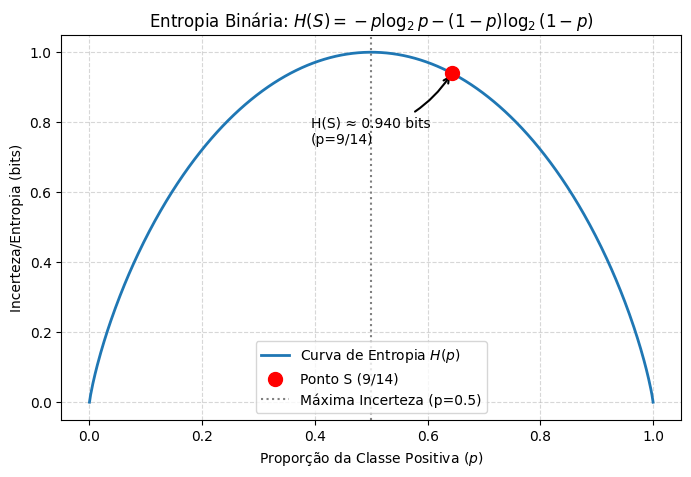

**Figura 22:** Curva de Entropia Binária e o Ponto H(S) calculado.


In [173]:
# @title { display-mode: "form" }
# 1. Definição da Função de Entropia Binária
def calcular_entropia_binaria(p):
    """Calcula H(p) = -p*log2(p) - (1-p)*log2(1-p)."""
    # Evita log(0) clipando p muito próximo de 0 e 1
    p_clip = np.clip(p, 1e-15, 1 - 1e-15)
    return -p_clip * np.log2(p_clip) - (1 - p_clip) * np.log2(1 - p_clip)

# 2. Configuração dos Dados para o Gráfico
# Eixo X: Proporção p variando de 0 a 1
p_eixo = np.linspace(0, 1, 500)
h_eixo = calcular_entropia_binaria(p_eixo)

# Ponto Alvo calculado na teoria (p = 9 positivos / 14 total)
p_alvo = 9/14
h_alvo = calcular_entropia_binaria(p_alvo)

# 3. Geração do Gráfico (Matplotlib)
plt.figure(figsize=(8, 5)) # Define tamanho adequado para o livro

# Plota a curva principal
plt.plot(p_eixo, h_eixo, label='Curva de Entropia $H(p)$', color='#1f77b4', lw=2)

# Destaca o ponto calculado (9/14)
plt.scatter([p_alvo], [h_alvo], color='red', s=100, zorder=5, label='Ponto S (9/14)')

# Adiciona anotação didática apontando para o ponto
texto_anotacao = f'H(S) ≈ {h_alvo:.3f} bits\n(p=9/14)'
plt.annotate(texto_anotacao, xy=(p_alvo, h_alvo), 
             xytext=(p_alvo - 0.25, h_alvo - 0.2), 
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', lw=1.5))

# Títulos e Rótulos formatados
plt.title('Entropia Binária: $H(S) = -p \log_2 p - (1-p) \log_2 (1-p)$')
plt.xlabel(f'Proporção da Classe Positiva ($p$)')
plt.ylabel('Incerteza/Entropia (bits)')

# Configurações visuais finais
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=0.5, color='gray', linestyle=':', label='Máxima Incerteza (p=0.5)')
plt.legend(loc='lower center')

# Exibe o gráfico no output do bloco
plt.show()

O resultado desta análise é apresentado na [Tabela 3.18](#tbl-3-pratica1), gerada pelo código a seguir.

In [174]:
# 1. Base de Dados: Tabela do Tempo (via String Bruta)
csv_raw = """Dia,Temperatura,Umidade,Vento,Partida
Ensolarado,Elevada,Alta,Falso,Não
Ensolarado,Elevada,Alta,Verdadeiro,Não
Nublado,Elevada,Alta,Falso,Sim
Chuvoso,Amena,Alta,Falso,Sim
Chuvoso,Baixa,Normal,Falso,Sim
Chuvoso,Baixa,Normal,Verdadeiro,Não
Nublado,Baixa,Normal,Verdadeiro,Sim
Ensolarado,Amena,Alta,Falso,Não
Ensolarado,Baixa,Normal,Falso,Sim
Chuvoso,Amena,Normal,Falso,Sim
Ensolarado,Amena,Normal,Verdadeiro,Sim
Nublado,Amena,Alta,Verdadeiro,Sim
Nublado,Elevada,Normal,Falso,Sim
Chuvoso,Amena,Alta,Verdadeiro,Não"""

df_tempo = pd.read_csv(io.StringIO(csv_raw))
ATRIBUTOS = ["Dia", "Temperatura", "Umidade", "Vento"]
CLASSE = "Partida"

# 2. Funções de Entropia e Ganho de Informação
def entropia(subset, classe=CLASSE):
    contagens = Counter(ex[classe] for ex in subset)
    total = len(subset)
    if total == 0: return 0.0
    return -sum((c/total) * math.log2(c/total) for c in contagens.values() if c > 0)

def ganho_informacao(subset, atributo, classe=CLASSE):
    h_s = entropia(subset, classe)
    total = len(subset)
    valores = set(ex[atributo] for ex in subset)
    soma_p = 0
    for v in valores:
        s_v = [ex for ex in subset if ex[atributo] == v]
        soma_p += (len(s_v) / total) * entropia(s_v, classe)
    return h_s - soma_p

# 3. Processamento
# Converter para lista de registros apenas para as funções de cálculo puras
dados_lista = df_tempo.to_dict(orient="records")
h_total = entropia(dados_lista)
resultados_p1 = []

for attr in ATRIBUTOS:
    gain = ganho_informacao(dados_lista, attr)
    resultados_p1.append({
        "Atributo": attr, 
        "Entropia Ponderada": f"{h_total - gain:.4f} bits",
        "Ganho de Informação": f"{gain:.4f} bits"
    })

df_p1 = pd.DataFrame(resultados_p1).sort_values(
    "Ganho de Informação", ascending=False).reset_index(drop=True)
df_p1["Ranking"] = ["🥇 Melhor (raiz)", "🥈", "🥉", "4º"]

print(f"Entropia total do conjunto S: H(S) = {h_total:.4f} bits\n")
Markdown(df_p1.to_markdown(index=False, colalign=("center",) * len(df_p1.columns)))

Entropia total do conjunto S: H(S) = 0.9403 bits



**Tabela 3.18:** Ganho de Informação por Atributo — Base Tabela do Tempo.


|  Atributo   |  Entropia Ponderada  |  Ganho de Informação  |     Ranking      |
|:-----------:|:--------------------:|:---------------------:|:----------------:|
|     Dia     |     0.6935 bits      |      0.2467 bits      | 🥇 Melhor (raiz) |
|   Umidade   |     0.7885 bits      |      0.1518 bits      |        🥈        |
|    Vento    |     0.8922 bits      |      0.0481 bits      |        🥉        |
| Temperatura |     0.9111 bits      |      0.0292 bits      |        4º        |

### 🔹 Prática 2 — Construção Recursiva da Árvore de Decisão (ID3)

Com o critério de seleção definido (máximo Ganho de Informação), podemos implementar o algoritmo **ID3** de forma recursiva. A ideia é simples:

1. Se todos os exemplos pertencem à mesma classe → cria um **nó folha** com essa classe.
2. Se não há mais atributos → cria um nó folha com a classe **majoritária**.
3. Caso contrário → escolhe o atributo com maior Ganho, divide os exemplos pelos valores desse atributo e repete recursivamente.

Nesta prática, a árvore é construída sobre a **Tabela do Tempo** e suas regras de classificação são exibidas na [Tabela 3.19](#tbl-3-pratica2), gerada pelo código a seguir.

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática depende do **dataset** e das **funções** definidas na Prática 1.


In [175]:
# 1. Algoritmo ID3 recursivo
def id3(subset, atributos_disponiveis, classe, profundidade=0):
    """Constrói recursivamente a Árvore de Decisão pelo critério ID3."""
    classes = [ex[classe] for ex in subset]

    # Caso base 1: todos da mesma classe
    if len(set(classes)) == 1:
        return {"folha": True, "classe": classes[0], "exemplos": len(subset)}

    # Caso base 2: sem atributos restantes
    if not atributos_disponiveis:
        majoritaria = Counter(classes).most_common(1)[0][0]
        return {"folha": True, "classe": majoritaria, "exemplos": len(subset)}

    # Escolha do melhor atributo
    gains = {a: ganho_informacao(subset, a, classe) for a in atributos_disponiveis}
    melhor = max(gains, key=gains.get)

    no = {"folha": False, "atributo": melhor, "gain": gains[melhor],
          "exemplos": len(subset), "filhos": {}}

    for valor in sorted(set(ex[melhor] for ex in subset)):
        subconjunto = [ex for ex in subset if ex[melhor] == valor]
        novos_atributos = [a for a in atributos_disponiveis if a != melhor]
        no["filhos"][valor] = id3(subconjunto, novos_atributos, classe, profundidade + 1)

    return no

# 2. Construção da árvore (passando CLASSE explicitamente)
arvore = id3(dados_lista, ATRIBUTOS.copy(), CLASSE)

# 3. Extração das Regras de Classificação
def extrair_regras(no, caminho=None):
    """Percorre a árvore e extrai as regras IF-THEN."""
    if caminho is None:
        caminho = []
    if no["folha"]:
        condicoes = " e ".join([f"{a}={v}" for a, v in caminho])
        return [(condicoes, no["classe"], no["exemplos"])]
    regras = []
    for valor, filho in no["filhos"].items():
        regras.extend(extrair_regras(filho, caminho + [(no["atributo"], valor)]))
    return regras

regras = extrair_regras(arvore)
resultados_p2 = [
    {"Condição (SE...)": cond, "Classe (ENTÃO)": cls, "Exemplos Cobertos": n}
    for cond, cls, n in regras
]
df_p2 = pd.DataFrame(resultados_p2)
print(f"Atributo Raiz: '{arvore['atributo']}' (Ganho = {arvore['gain']:.4f} bits)\n")
print(f"Total de regras extraídas: {len(regras)}\n")
Markdown(df_p2.to_markdown(index=False, colalign=("left", "center", "center")))


Atributo Raiz: 'Dia' (Ganho = 0.2467 bits)

Total de regras extraídas: 5



**Tabela 3.19:** Regras de Classificação Extraídas da Árvore de Decisão ID3.


| Condição (SE...)                |  Classe (ENTÃO)  |  Exemplos Cobertos  |
|:--------------------------------|:----------------:|:-------------------:|
| Dia=Chuvoso e Vento=Falso       |       Sim        |          3          |
| Dia=Chuvoso e Vento=Verdadeiro  |       Não        |          2          |
| Dia=Ensolarado e Umidade=Alta   |       Não        |          3          |
| Dia=Ensolarado e Umidade=Normal |       Sim        |          2          |
| Dia=Nublado                     |       Sim        |          4          |

### 🔹 Prática 3 — Visualização Gráfica da Árvore e Matriz de Confusão

Uma Árvore de Decisão vale mais quando podemos **vê-la**. Nesta prática, visualizamos a árvore construída pelo ID3 e avaliamos seu desempenho calculando a **Matriz de Confusão** e a **Acurácia**.

A **Matriz de Confusão** organiza os resultados em quatro quadrantes:

| | Previsto Sim | Previsto Não |
|---|---|---|
| **Real Sim** | Verdadeiro Positivo (VP) | Falso Negativo (FN) |
| **Real Não** | Falso Positivo (FP) | Verdadeiro Negativo (VN) |

$$\text{Acurácia} = \frac{VP + VN}{VP + VN + FP + FN}$$

A [Figura 3.23](#fig-3-pratica3a) mostra a árvore induzida e a [Figura 3.24](#fig-3-pratica3b) a Matriz de Confusão sobre o conjunto de treinamento, ambas geradas pelo código a seguir.

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática depende da variável `arvore`, do `df_tempo` e das funções das Práticas 1 e 2.

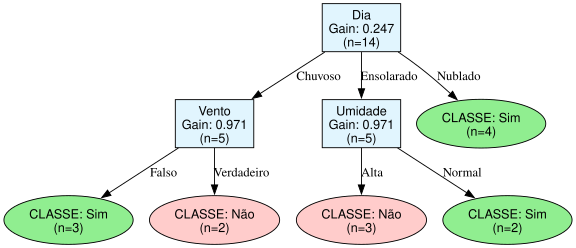

**Figura 3.23:** Árvore de Decisão ID3 construída sobre a Tabela do Tempo.


In [176]:
# ─── Visualização da Árvore ────────────────────────────────────────────────
def construir_arvore_viz(no, dot=None, pai=None, edge_label=""):
    if dot is None:
        # Correção: O nome correto da classe é Digraph
        dot = graphviz.Digraph(comment='Árvore de Decisão ID3')
        dot.attr(rankdir='TB', size='8,5')
        dot.attr('node', shape='rectangle', style='filled', fontname='Helvetica')

    # Identificador único para o nó baseado na posição de memória
    no_id = str(id(no))

    if no['folha']:
        # Estilização para Folhas (Nó de Classe)
        cor = '#90ee90' if no['classe'] == 'Sim' else '#ffcccb'
        label = f"CLASSE: {no['classe']}\n(n={no['exemplos']})"
        dot.node(no_id, label, shape='ellipse', fillcolor=cor)
    else:
        # Estilização para Nós de Decisão (Atributos)
        label = f"{no['atributo']}\nGain: {no['gain']:.3f}\n(n={no['exemplos']})"
        dot.node(no_id, label, fillcolor='#e1f5fe')

    if pai:
        dot.edge(pai, no_id, label=edge_label)

    # Recursão para processar os filhos
    if not no['folha']:
        for valor, filho in no['filhos'].items():
            construir_arvore_viz(filho, dot, no_id, valor)
            
    return dot

# Gerar e exibir no Jupyter/Quarto
viz = construir_arvore_viz(arvore)
display(viz)

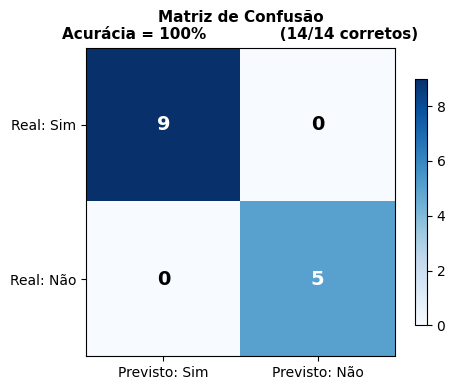

**Figura 3.24:** Matriz de Confusão — Avaliação sobre o Conjunto de Treinamento.



📊 Resumo da Avaliação:
   Acurácia     : 100.00%
   VP (Sim→Sim) : 9
   VN (Não→Não) : 5
   FP (Não→Sim) : 0
   FN (Sim→Não) : 0


In [177]:
# ─── Classificador e Matriz de Confusão ────────────────────────────────────
def classificar(exemplo, no):
    """Classifica um exemplo percorrendo a árvore recursivamente."""
    if no["folha"]:
        return no["classe"]
    atributo = no["atributo"]
    valor = exemplo.get(atributo)
    if valor in no["filhos"]:
        return classificar(exemplo, no["filhos"][valor])
    # Fallback: classe majoritária (não ocorre neste dataset, mas é boa prática)
    contagens = Counter()
    def coletar_classes(n):
        if n["folha"]:
            contagens[n["classe"]] += n["exemplos"]
        else:
            for f in n["filhos"].values():
                coletar_classes(f)
    coletar_classes(no)
    return contagens.most_common(1)[0][0]

# Classificação de todos os exemplos de treinamento
predicoes = [classificar(ex, arvore) for ex in dados_lista]
reais     = [ex[CLASSE] for ex in dados_lista]
classes   = ["Sim", "Não"]

# Construção da matriz
matriz = {c_real: {c_pred: 0 for c_pred in classes} for c_real in classes}
for real, pred in zip(reais, predicoes):
    matriz[real][pred] += 1

# Dados para o heatmap
z = np.array([[matriz[c_real][c_pred] for c_pred in classes] for c_real in classes])
acuracia = sum(z[i][i] for i in range(len(classes))) / len(reais)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(z, cmap="Blues", vmin=0, vmax=z.max())

for i in range(len(classes)):
    for j in range(len(classes)):
        cor_txt = "white" if z[i, j] > z.max() / 2 else "black"
        ax.text(j, i, str(z[i, j]), ha="center", va="center",
                fontsize=14, fontweight="bold", color=cor_txt)

ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels([f"Previsto: {c}" for c in classes], fontsize=10)
ax.set_yticklabels([f"Real: {c}" for c in classes], fontsize=10)
ax.set_title(f"Matriz de Confusão\nAcurácia = {acuracia:.0%} \
             ({int(acuracia*len(reais))}/{len(reais)} corretos)",
             fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"\n📊 Resumo da Avaliação:")
print(f"   Acurácia     : {acuracia:.2%}")
print(f"   VP (Sim→Sim) : {matriz['Sim']['Sim']}")
print(f"   VN (Não→Não) : {matriz['Não']['Não']}")
print(f"   FP (Não→Sim) : {matriz['Não']['Sim']}")
print(f"   FN (Sim→Não) : {matriz['Sim']['Não']}")

### 🔹 Prática 4 — Dataset Iris e Scikit-learn

O dataset **Iris** (Fisher (1936)) é o "olá mundo" do Aprendizado de Máquina — 150 exemplos de flores divididos em 3 espécies (*Setosa*, *Versicolor*, *Virginica*) descritas por 4 atributos contínuos. Ele é perfeitamente adequado para demonstrar Árvores de Decisão com atributos numéricos.

Nesta prática utilizamos a biblioteca **Scikit-learn** para:

1. Treinar uma Árvore de Decisão (`DecisionTreeClassifier`) com o critério de **Entropia** (equivalente ao ID3).
2. Visualizar a árvore aprendida.
3. Avaliar o modelo com **validação cruzada** (*k-fold cross-validation*) — uma técnica mais robusta do que usar apenas o conjunto de treinamento.

A [Figura 3.25](#fig-3-pratica4a) apresenta a árvore gerada e a [Figura 3.26](#fig-3-pratica4b) a acurácia por fold da validação cruzada.

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática é independente das anteriores. Certifique-se de ter executado o **Bloco de Importações** antes de prosseguir.

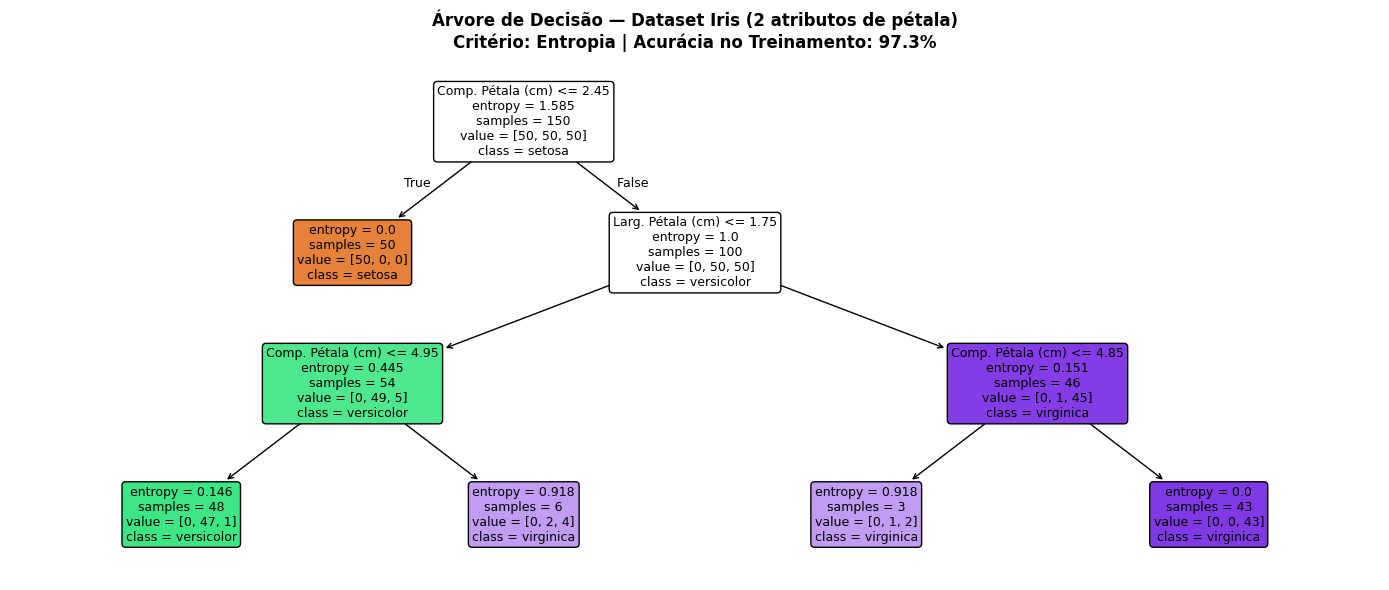

**Figura 3.25:** Árvore de Decisão treinada com Scikit-learn no dataset Iris (apenas pétalas).



🌸 Profundidade da Árvore : 3 níveis
🍃 Número de Nós Folha    : 5
📈 Acurácia (Treinamento) : 97.33%


In [178]:
# 1. Carregamento e seleção de atributos (pétalas apenas — igual ao exercício do capítulo)
iris = load_iris()
X_iris = iris.data[:, 2:]   # petallength, petalwidth
y_iris = iris.target
nomes_features = ["Comp. Pétala (cm)", "Larg. Pétala (cm)"]
nomes_classes  = iris.target_names

# 2. Treinamento
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
clf.fit(X_iris, y_iris)
acuracia_treino = clf.score(X_iris, y_iris)

# 3. Visualização da Árvore
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(clf, feature_names=nomes_features, class_names=nomes_classes,
          filled=True, rounded=True, fontsize=9, ax=ax,
          impurity=True, proportion=False)
ax.set_title(f"Árvore de Decisão — Dataset Iris (2 atributos de pétala)\n"
             f"Critério: Entropia | Acurácia no Treinamento: {acuracia_treino:.1%}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n🌸 Profundidade da Árvore : {clf.get_depth()} níveis")
print(f"🍃 Número de Nós Folha    : {clf.get_n_leaves()}")
print(f"📈 Acurácia (Treinamento) : {acuracia_treino:.2%}")

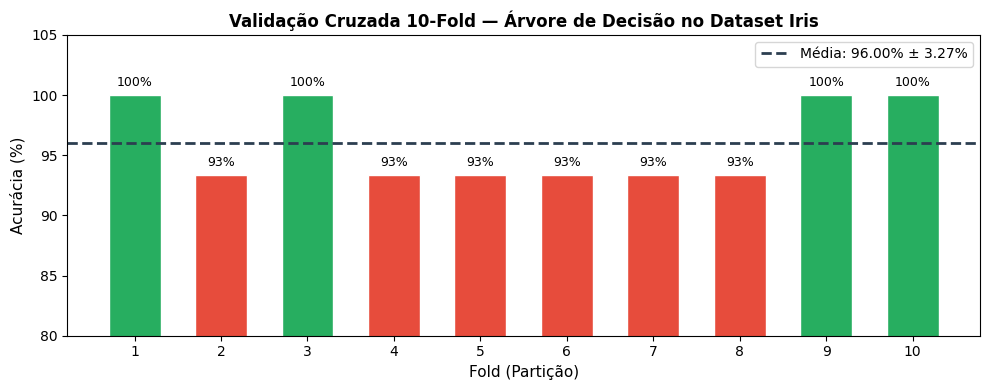

**Figura 3.26:** Validação Cruzada (10-fold) — Acurácia por Partição.



📊 Validação Cruzada 10-Fold:
   Acurácia Média : 96.00%
   Desvio Padrão  : 3.27%
   Melhor Fold    : 100.00% (Fold 1)
   Pior Fold      : 93.33% (Fold 2)


In [179]:
# 4. Validação Cruzada (clf e X_iris, y_iris definidos na célula anterior)
K = 10
scores = cross_val_score(clf, X_iris, y_iris, cv=K, scoring="accuracy")
media  = scores.mean()
desvio = scores.std()

# 5. Gráfico de barras por fold
fig, ax = plt.subplots(figsize=(10, 4))
cores = ["#27ae60" if s >= media else "#e74c3c" for s in scores]
bars = ax.bar(range(1, K + 1), scores * 100, color=cores, edgecolor="white", width=0.6)

ax.axhline(media * 100, color="#2c3e50", linewidth=2, linestyle="--",
           label=f"Média: {media:.2%} ± {desvio:.2%}")
ax.set_xlabel("Fold (Partição)", fontsize=11)
ax.set_ylabel("Acurácia (%)", fontsize=11)
ax.set_title(f"Validação Cruzada {K}-Fold — Árvore de Decisão no Dataset Iris",
             fontsize=12, fontweight="bold")
ax.set_xticks(range(1, K + 1))
ax.set_ylim([80, 105])
ax.legend(fontsize=10)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{score:.0%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n📊 Validação Cruzada {K}-Fold:")
print(f"   Acurácia Média : {media:.2%}")
print(f"   Desvio Padrão  : {desvio:.2%}")
print(f"   Melhor Fold    : {scores.max():.2%} (Fold {scores.argmax()+1})")
print(f"   Pior Fold      : {scores.min():.2%} (Fold {scores.argmin()+1})")

### 🔹 Prática 5 — Overfitting, Poda e Comparação de Profundidades

O **superajuste (*overfitting*)** é um dos problemas centrais em Aprendizado de Máquina. Uma Árvore de Decisão muito profunda memoriza os dados de treinamento — incluindo ruídos — e perde a capacidade de generalizar para novos exemplos.

Nesta prática, treinamos **múltiplas árvores** com diferentes profundidades máximas (`max_depth`) e observamos:

- Como a **acurácia no treinamento** tende a 100% com o aumento da profundidade.
- Como a **acurácia na validação cruzada** atinge um pico e depois **piora** — sinal claro de overfitting.
- Qual a **profundidade ótima** que equilibra complexidade e generalização.

A [Figura 3.27](#fig-3-pratica5) mostra este comportamento, gerada pelo código a seguir.

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática depende do dataset `iris` e do `DecisionTreeClassifier` carregados na Prática 4.

**Desafio:** Observe o gráfico e responda: a partir de qual profundidade ocorre overfitting no dataset Iris? Como a **poda** poderia ser aplicada para evitá-lo?

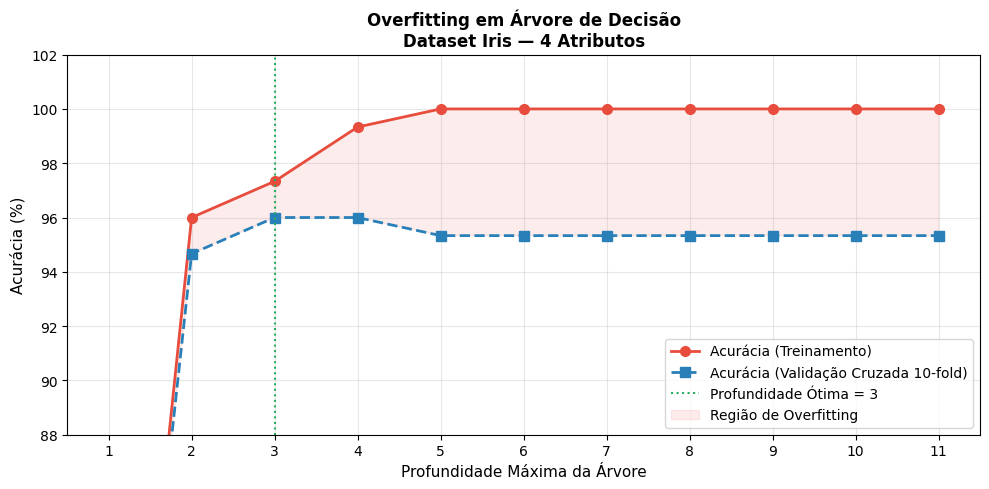

**Figura 3.27:** Overfitting: Acurácia de Treinamento vs. Validação Cruzada por Profundidade.



🎯 Resultados por Profundidade:
 Depth |   Treino |  CV (10-fold) |  Gap (Overfit)
--------------------------------------------------
     1 |   66.67% |        66.67% |        -0.00%
     2 |   96.00% |        94.67% |         1.33%
     3 |   97.33% |        96.00% |         1.33% ← ótima
     4 |   99.33% |        96.00% |         3.33%
     5 |  100.00% |        95.33% |         4.67%
     6 |  100.00% |        95.33% |         4.67%
     7 |  100.00% |        95.33% |         4.67%
     8 |  100.00% |        95.33% |         4.67%
     9 |  100.00% |        95.33% |         4.67%
    10 |  100.00% |        95.33% |         4.67%
    11 |  100.00% |        95.33% |         4.67%


In [180]:
iris = load_iris()
X_full = iris.data   # Todos os 4 atributos
y_full = iris.target

profundidades = range(1, 12)
acuracias_treino = []
acuracias_cv     = []

for depth in profundidades:
    modelo = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    modelo.fit(X_full, y_full)
    acuracias_treino.append(modelo.score(X_full, y_full))
    cv_scores = cross_val_score(modelo, X_full, y_full, cv=10, scoring="accuracy")
    acuracias_cv.append(cv_scores.mean())

# Melhor profundidade pela CV
melhor_depth = list(profundidades)[np.argmax(acuracias_cv)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(profundidades, [a * 100 for a in acuracias_treino],
        "o-", color="#e74c3c", linewidth=2, markersize=7, label="Acurácia (Treinamento)")
ax.plot(profundidades, [a * 100 for a in acuracias_cv],
        "s--", color="#2980b9", linewidth=2, markersize=7, label="Acurácia (Validação Cruzada 10-fold)")
ax.axvline(melhor_depth, color="#27ae60", linewidth=1.5, linestyle=":",
           label=f"Profundidade Ótima = {melhor_depth}")
ax.fill_between(profundidades,
                [a * 100 for a in acuracias_treino],
                [a * 100 for a in acuracias_cv],
                alpha=0.1, color="#e74c3c", label="Região de Overfitting")

ax.set_xlabel("Profundidade Máxima da Árvore", fontsize=11)
ax.set_ylabel("Acurácia (%)", fontsize=11)
ax.set_title("Overfitting em Árvore de Decisão\nDataset Iris — 4 Atributos",
             fontsize=12, fontweight="bold")
ax.set_xticks(list(profundidades))
ax.set_ylim([88, 102])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🎯 Resultados por Profundidade:")
print(f"{'Depth':>6} | {'Treino':>8} | {'CV (10-fold)':>13} | {'Gap (Overfit)':>14}")
print("-" * 50)
for d, tr, cv in zip(profundidades, acuracias_treino, acuracias_cv):
    marca = " ← ótima" if d == melhor_depth else ""
    print(f"{d:>6} | {tr:>8.2%} | {cv:>13.2%} | {(tr-cv):>13.2%}{marca}")

### Conclusão do Ciclo de Aprendizado

Através destas cinco práticas, percorremos toda a jornada de uma Árvore de Decisão:

1. **Entropia e Ganho** — Quantificamos matematicamente a qualidade de cada atributo como nó de decisão, replicando o raciocínio intuitivo da teoria.
2. **Algoritmo ID3** — Construímos a árvore recursivamente do zero, extraindo as Regras de Classificação diretamente do modelo.
3. **Visualização e Matriz de Confusão** — Tornamos o modelo interpretável graficamente e avaliamos seus acertos e erros.
4. **Scikit-learn e Validação Cruzada** — Aplicamos o classificador a um dataset real (Iris) com avaliação mais robusta do que o simples uso do conjunto de treinamento.
5. **Overfitting e Poda** — Demonstramos empiricamente o problema do superajuste e identificamos a profundidade ótima para a árvore.

Estes conceitos formam a base para métodos mais avançados, como **Random Forests** e **Gradient Boosting**, que estudaremos em capítulos futuros.

## 🤖 Uso do NotebookLM como Tutor Complementar

Seguindo o padrão do capítulo anterior, além dos notebooks interativos no Google Colab, incentiva-se o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Essa ferramenta de IA utiliza exclusivamente os documentos fornecidos pelos autores como base de conhecimento, garantindo respostas alinhadas ao conteúdo do livro.

Para cada capítulo, foi preparado um projeto específico na plataforma. Para uma experiência de estudo ampliada, utilize o acesso abaixo:

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> Para interagir com o conteúdo deste capítulo, acesse o link abaixo. O ambiente contém materiais didáticos em diferentes formatos, gerados a partir do **PDF** do capítulo. Na plataforma, explore especialmente as opções **Guia de Estudo** e **Conversa** para aprofundar sua compreensão. 
>
> Por exemplo, use perguntas como: *"Explique o critério ID3 com um exemplo diferente"*, *"Qual a diferença entre Entropia e Índice Gini?"* ou *"O que é overfitting e como a poda resolve este problema?"*.
>
>
> [🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 03](https://notebooklm.google.com/notebook/f0beb039-7a4c-40c9-a476-4f4ef8418580)


## Considerações Finais

A geração de Árvores de Decisão normalmente é comparativamente mais
rápida que outros métodos de classificação. Árvores de Decisão pequenas
são fáceis de entender e Árvores grandes podem ser convertidas em Regras
de Classificação. Geralmente a taxa de acerto de classificação de
Exemplos de Teste, ou seja, a Acurácia das Árvores de Decisão, é
compatível com outros métodos equivalentes, ou um pouco abaixo de
métodos mais complexos. Porém, em Aprendizado de Máquina raramente se
encontra um método com desempenho superior que seus pares para qualquer
conjunto de dados.

Não foram estudados aqui casos reais de inconsistências, ausência de
dados ou exceções na Base de Dados, para citar apenas alguns dos
possíveis problemas. Suponha que durante a indução da Árvore de Decisão
dois Exemplos ligeiramente distintos, mas que percorrem o mesmo caminho,
pertençam a classes distintas! Neste caso, verifica-se que há
inconsistência nos dados e uma análise pontual deverá determinar e
eliminar o problema. Considere casos reais de Exemplos ausentes
representados por caminhos logicamente possíveis, como um dos valores
possíveis que determinado atributo pode assumir, mas que não estão
presentes na Base de Dados. Que classe atribuir a estes casos? Algum
critério deverá ser adotado para estes casos, como o de atribuir o valor
da classe estatisticamente predominante no conjunto de Exemplos.

Além dessas situações, há os casos de dados espúrios causados por coleta
equivocada, mas com valores lógicos perfeitamente dentro das
possibilidades aceitas para cada atributo, e que não terão sido
detectados na fase inicial de limpeza de dados porque a natureza desses
problemas é de incompatibilidade com o modelo gerado ou o conceito
aprendido. O tratamento de problemas desta natureza foge ao escopo desta
primeira abordagem à geração ou indução de Árvores de Decisão, mas tais
problemas podem ser estudados na referência bibliográfica fornecida na
parte final deste material.

## Lista de Exercícios

1\. (20%) Explique **com suas próprias palavras** a seguinte afirmação:
numa **Árvore de Decisão**, os nós testam **Atributos**.

2\. (30%) Explique **com suas próprias palavras**, o que é "superajuste"
ou "*overfitting*", seus efeitos e dê um exemplo.

3\. Carregue o arquivo "iris.arff" (anexo) no Weka e elimine os
atributos "sepalwidth" (largura da sépala) e "sepallength" (comprimento
da sépala). Para fazer esta operação, basta selecionar estes dois
atributos no "Weka Explorer" e depois clicar em "Remove". Devem sobrar
apenas três atributos: "petallength" (comprimento da pétala),
"petalwidth" (largura da pétala) e "class" (classe), com 150 Exemplos,
divididos entre "Iris-setosa", "Iris-versicolor" e "Iris-virginica".

\(a\) (30%) -- Gere a Árvore de Decisão com o algoritmo "J4.8", analise a
representação gráfica da árvore e explique por que esta Árvore de
Decisão deve cometer menos erros de classificação que a Árvore de
Decisão da Figura 3.2, de nosso material didático.

\(b\) (20%) -- No "Weka Explorer", vá em "Visualize", ajuste "PlotSize"
e "PointSize", clique em "Update" e escolha a representação com os
atributos "petalwidth" e "petallength". Analise esta figura (que deve se
parecer à Figura 3.1 de nosso material didático).

## Referências do Capítulo


Este capítulo baseou-se em obras clássicas e manuais técnicos que definem o estado da arte em ciência de dados. A fundamentação teórica sobre a indução de árvores de decisão seguiu o trabalho seminal de Quinlan (1986), complementado pelas metodologias de mineração e descoberta de conhecimento exploradas em Han e Kamber (2008) e Tan et al. (2009). As implementações práticas e o uso da ferramenta Weka fundamentam-se em Witten e Frank (2005) e Frank et al. (2016). Para a contextualização no cenário de sistemas inteligentes e análise de dados, foram consultadas as obras de Rezende (2005), Pinheiro (2008) e Rocha et al. (2008). Por fim, o conjunto de dados histórico utilizado em diversos exemplos práticos remete ao estudo de Fisher (1936).

FISHER, Ronald A. **The Use of Multiple Measurements in Taxonomic Problems**. 1936.

FRANK, Eibe; HALL, Mark A.; WITTEN, Ian H. **The {WEKA} Workbench. Online Appendix for "Data Mining: Practical Machine Learning Tools and Techniques"**. Morgan Kaufmann, 2016.

HAN, J.; KAMBER, M. **Data Mining: Concepts and Techniques**. Morgan Kaufmann Publishers, 2008.

PINHEIRO, C. A. R. **Inteligência Analítica: Mineração de Dados e Descoberta de Conhecimento**. Editora Ciência Moderna Ltda., 2008.

QUINLAN, R. **Induction of Decision Trees**. 1986.

REZENDE, S. O. **Sistemas Inteligentes: Fundamentos e Aplicações**. Editora Manole Ltda, 2005.

ROCHA, Miguel; CORTEZ, Paulo; NEVES, Jos{\'e} M. **Sem titulo**. Lisboa, Editora de Inform{\'a}tica, 2008.

TAN, P.N.; STEINBACH, M.; KUMAR, V. **Introdução ao Data Mining Mineração de Dados**. Editora Ciência Moderna Ltda., 2009.

WITTEN, I. H.; FRANK, E. **Data Mining: Practical Machine Learning Tools and Techniques**. Morgan Kaufmann Publishers, 2005.